# 1. Définir un objectif mesurable

## Objectif

Prédire si une personne est infectée en fonction des données cliniques disponibles

## Métrique

- accuracy(précision) TP/(TP+FP) -> on veut pas de faux positifs, on veut pas envoyer à l'hôpital pour rien
- recall(sensibilité) TP/(TP+FN) -> on veut pas de faux négatifs, on veut surtout pas louper un positif
- F1score

Problème : classes déséquilibrées, on a déjà 90% des exemples qui n'ont pas le virus donc on peut atteindre 0.9 accuracy
**Donc on ne choisit pas l'accuracy**

**Métrique** : F1 0.5 et Recall 0.7

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [24]:
link='/kaggle/input/covid19/dataset.xlsx'
data=pd.read_excel(link)
df=data.copy()
df.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Serum Glucose,Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Mycoplasma pneumoniae,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,Neutrophils,Urea,Proteina C reativa mg/dL,Creatinine,Potassium,Sodium,"Influenza B, rapid test","Influenza A, rapid test",Alanine transaminase,Aspartate transaminase,Gamma-glutamyltransferase,Total Bilirubin,Direct Bilirubin,Indirect Bilirubin,Alkaline phosphatase,Ionized calcium,Strepto A,Magnesium,pCO2 (venous blood gas analysis),Hb saturation (venous blood gas analysis),Base excess (venous blood gas analysis),pO2 (venous blood gas analysis),Fio2 (venous blood gas analysis),Total CO2 (venous blood gas analysis),pH (venous blood gas analysis),HCO3 (venous blood gas analysis),Rods #,Segmented,Promyelocytes,Metamyelocytes,Myelocytes,Myeloblasts,Urine - Esterase,Urine - Aspect,Urine - pH,Urine - Hemoglobin,Urine - Bile pigments,Urine - Ketone Bodies,Urine - Nitrite,Urine - Density,Urine - Urobilinogen,Urine - Protein,Urine - Sugar,Urine - Leukocytes,Urine - Crystals,Urine - Red blood cells,Urine - Hyaline cylinders,Urine - Granular cylinders,Urine - Yeasts,Urine - Color,Partial thromboplastin time (PTT),Relationship (Patient/Normal),International normalized ratio (INR),Lactic Dehydrogenase,"Prothrombin time (PT), Activity",Vitamin B12,Creatine phosphokinase (CPK),Ferritin,Arterial Lactic Acid,Lipase dosage,D-Dimer,Albumin,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,-0.140648,not_detected,not_detected,not_detected,not_detected,not_detected,detected,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,-0.619086,1.198059,-0.147895,2.089928,-0.305787,0.862512,negative,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
pd.set_option('display.max_row',111)
pd.set_option('display.max_column',111)

# 2. EDA (Exploratory Data Analysis)
**Objectif** : Comprendre au mieux les données pour définir une stratégie de modélisation.

* **Analyse de la forme :**
  * **Identification de la target** : SARS-Cov-2 exam result
  * **Nombre de lignes et colonnes** : 5644 x 111
  * **Type de variables** : qualitatives : 70, quantitatives : 41
  * **Identification des valeurs manquantes** :
    * beaucoup de NaN (moitié des variables > 90% de NaN)
    * 2 groupes de données 76% -> Test viral, 89% -> taux sanguin
    
* **Analyse du fond :**
  * **Visualisation de la target** :
    * 10% de cas positifs, 90% de négatifs
  * **Compréhension des différentes variables**
    * Variables continues standardisées, skewed (asymétriques)
    * Age quantile : difficile d'interpréter ce graphique, les données ont été traitées, on pourrait penser 0-5 mais cela pourrait être aussi une transformation mathématique
    * Variables qualitatives : binaire (0,1), viral, Rhinovirus semble élevée
  * **Visualisation des relations features-target**:
    * target/blood : taux de Monocytes, Platelets, Leukocytes semblent liés au covid -> hypothèse à tester
    * target / age : individus jeunes peu contaminés ? attention, on ne connait pas l'âge.
    * target / viral : doubles maladies sont rares. Rhinovirus/enterovirus positif - covid négatif ? -> hypothèse à tester ? possible que la région ait subi une épidémie de ce virus. On peut aussi avoir les deux en même temps.
  * **Identification des outliers**

### **Analyse de la forme**

## **Identification de la target**

In [19]:
target_feature='SARS-Cov-2 exam result'

## **Type de variables**

In [5]:
df.dtypes.value_counts()

float64    70
object     37
int64       4
Name: count, dtype: int64

## **Analyse des Valeurs manquantes**

<Axes: >

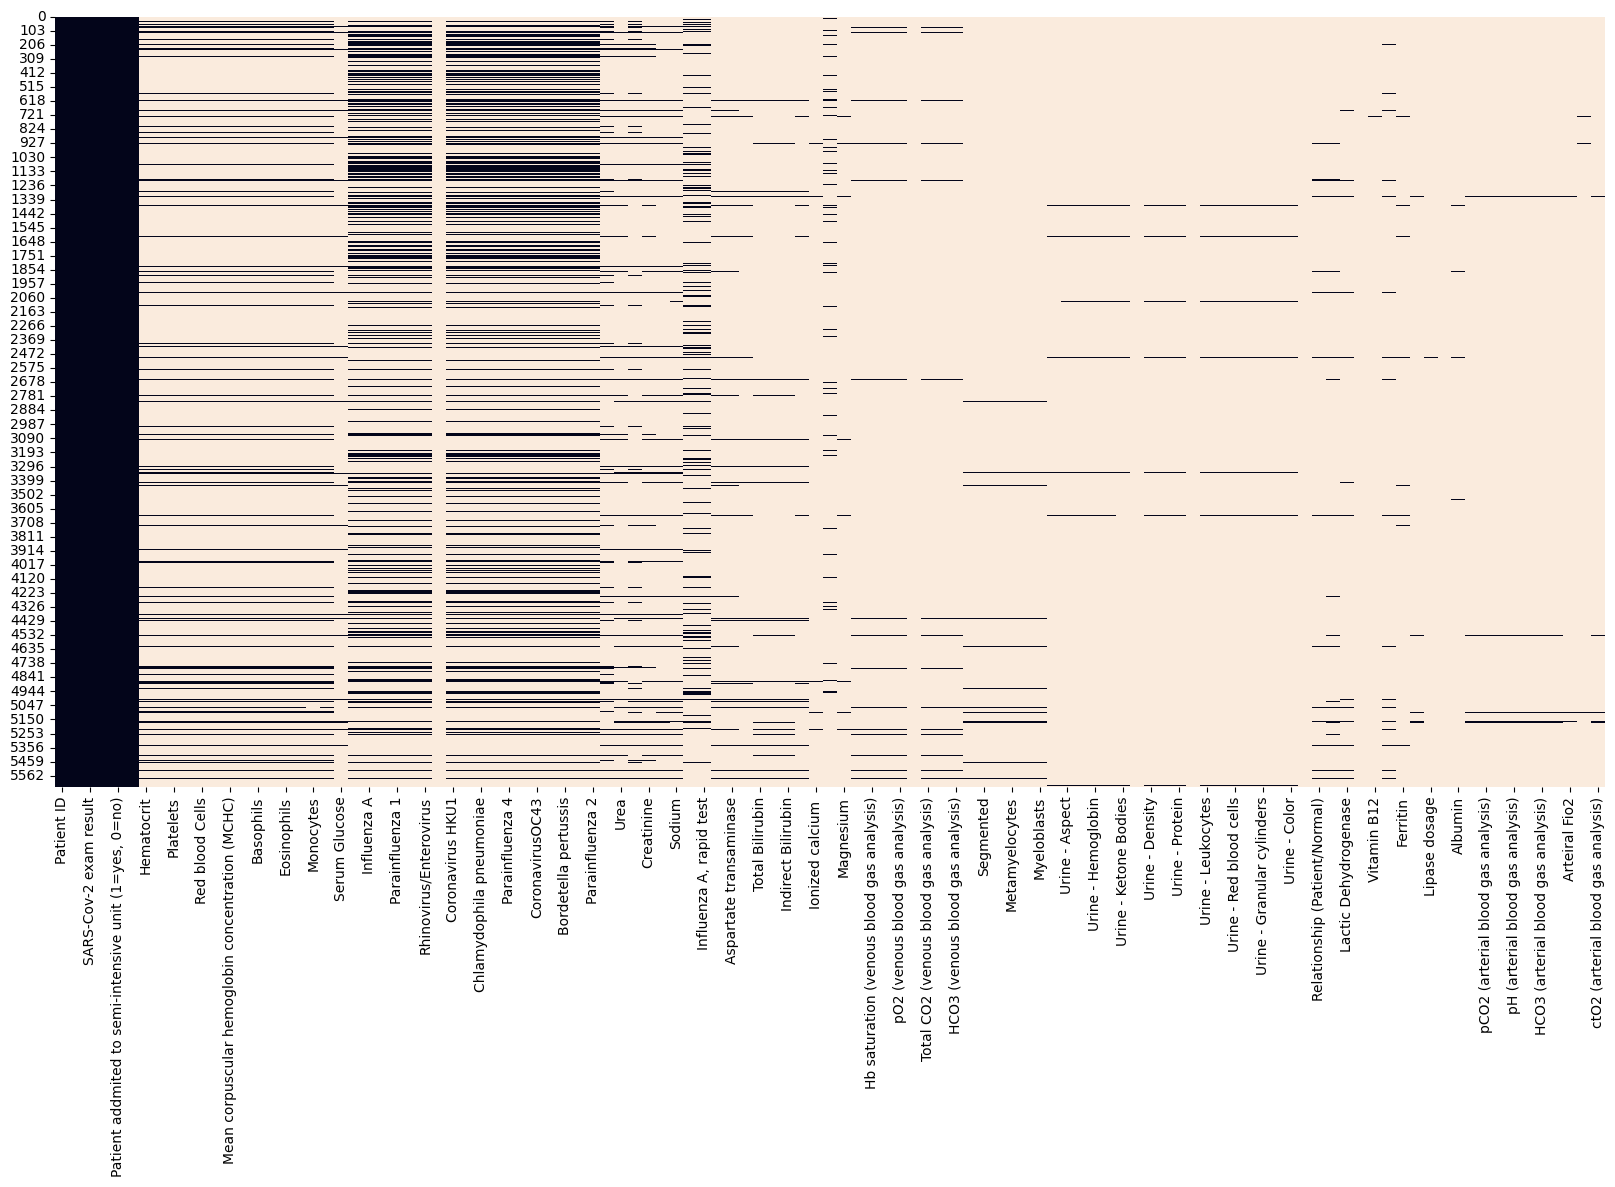

In [6]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(),cbar=False)
#Valeurs manquantes en blanc

In [7]:
print('Colonnes et pourcentage de valeurs manquantes :\n')
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

Colonnes et pourcentage de valeurs manquantes :



Patient ID                                               0.000000
Patient age quantile                                     0.000000
SARS-Cov-2 exam result                                   0.000000
Patient addmited to regular ward (1=yes, 0=no)           0.000000
Patient addmited to semi-intensive unit (1=yes, 0=no)    0.000000
Patient addmited to intensive care unit (1=yes, 0=no)    0.000000
Influenza B                                              0.760099
Respiratory Syncytial Virus                              0.760099
Influenza A                                              0.760099
Rhinovirus/Enterovirus                                   0.760454
Inf A H1N1 2009                                          0.760454
CoronavirusOC43                                          0.760454
Coronavirus229E                                          0.760454
Parainfluenza 4                                          0.760454
Adenovirus                                               0.760454
Chlamydoph

### **Analyse du fond**

## **Elimination des colonnes inutiles**

In [8]:
print('Les colonnes pour lequelles on a moins de 90% de valeur manquante :\n')
df.columns[df.isna().sum()/df.shape[0] < 0.9]

Les colonnes pour lequelles on a moins de 90% de valeur manquante :



Index(['Patient ID', 'Patient age quantile', 'SARS-Cov-2 exam result',
       'Patient addmited to regular ward (1=yes, 0=no)',
       'Patient addmited to semi-intensive unit (1=yes, 0=no)',
       'Patient addmited to intensive care unit (1=yes, 0=no)', 'Hematocrit',
       'Hemoglobin', 'Platelets', 'Mean platelet volume ', 'Red blood Cells',
       'Lymphocytes', 'Mean corpuscular hemoglobin concentration (MCHC)',
       'Leukocytes', 'Basophils', 'Mean corpuscular hemoglobin (MCH)',
       'Eosinophils', 'Mean corpuscular volume (MCV)', 'Monocytes',
       'Red blood cell distribution width (RDW)',
       'Respiratory Syncytial Virus', 'Influenza A', 'Influenza B',
       'Parainfluenza 1', 'CoronavirusNL63', 'Rhinovirus/Enterovirus',
       'Coronavirus HKU1', 'Parainfluenza 3', 'Chlamydophila pneumoniae',
       'Adenovirus', 'Parainfluenza 4', 'Coronavirus229E', 'CoronavirusOC43',
       'Inf A H1N1 2009', 'Bordetella pertussis', 'Metapneumovirus',
       'Parainfluenza 2', 'In

In [43]:
df=df[df.columns[df.isna().sum()/df.shape[0] < 0.9]]

<Axes: >

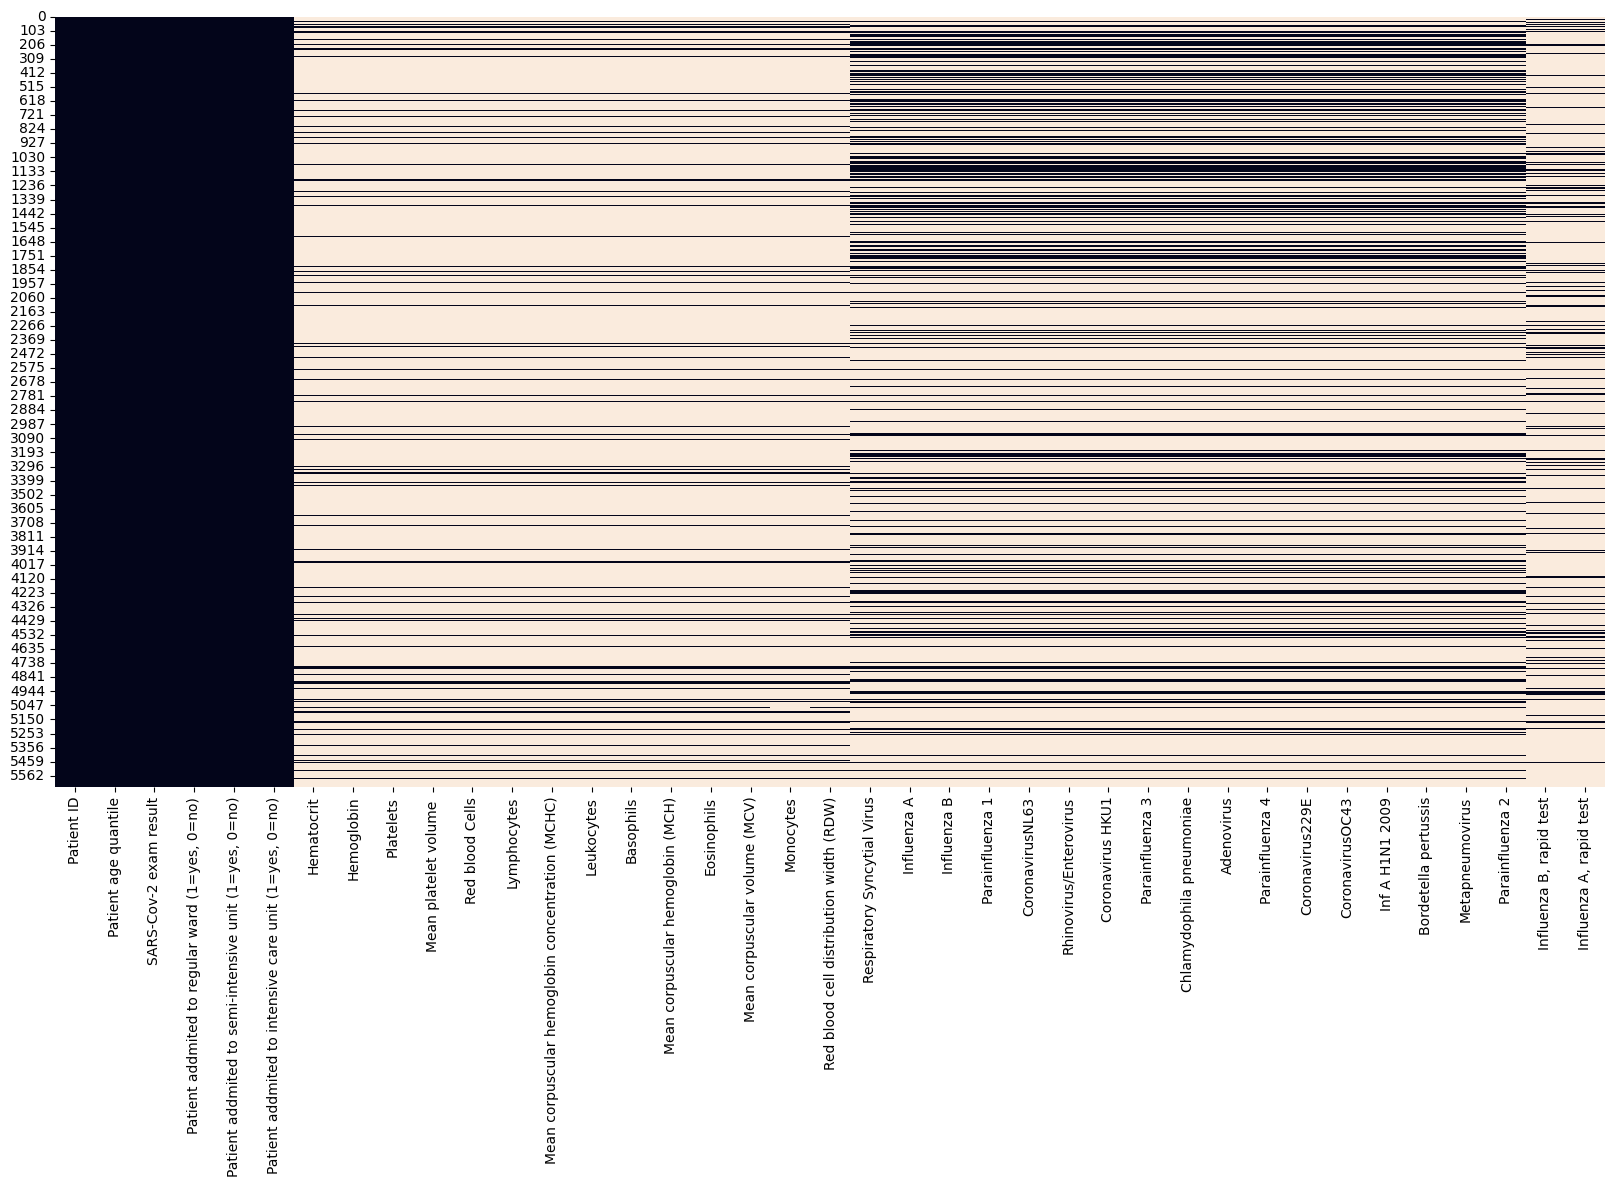

In [10]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(),cbar=False)
#Valeurs manquantes en blanc

In [44]:
df.drop('Patient ID',axis=1,inplace=True)

## **Visualisation de la target**

In [12]:
print(f'Répartition de {target_feature} :\n')
df[target_feature].value_counts(normalize=True)

Répartition de SARS-Cov-2 exam result :



SARS-Cov-2 exam result
negative    0.901134
positive    0.098866
Name: proportion, dtype: float64

## **Histogrammes des variables continues**

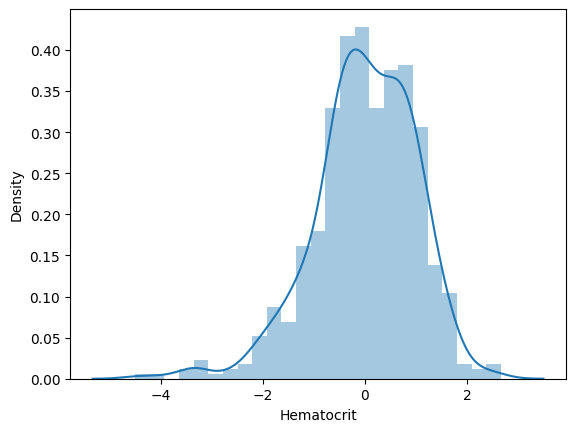

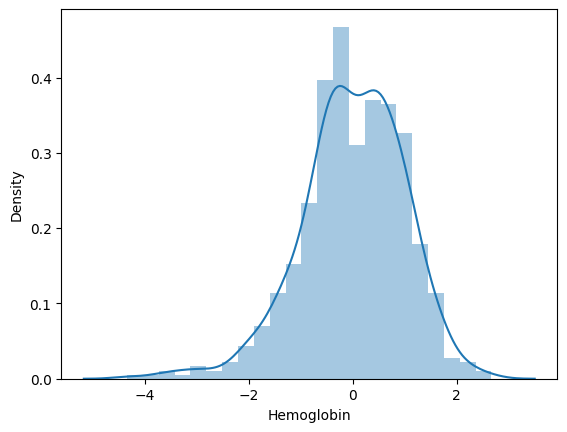

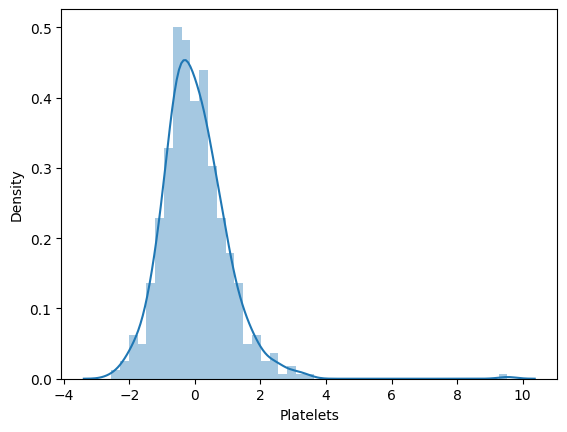

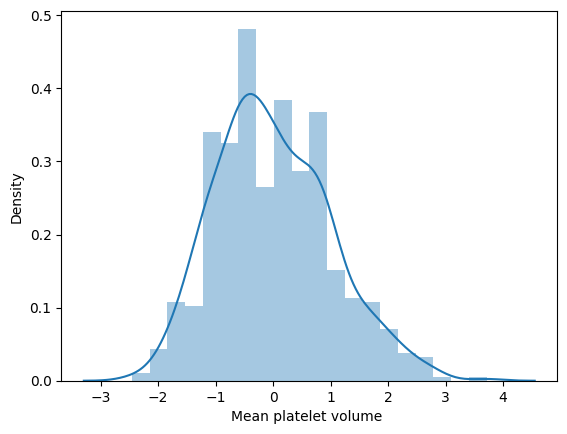

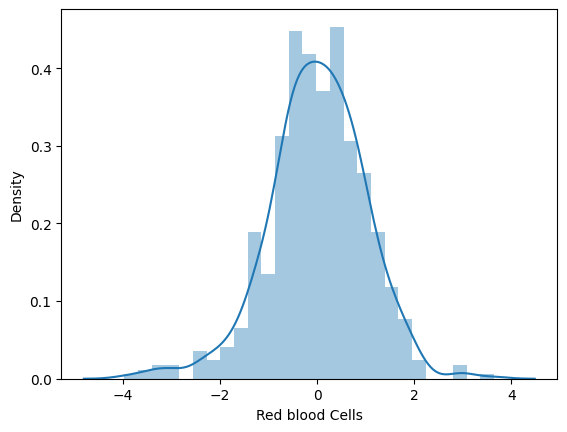

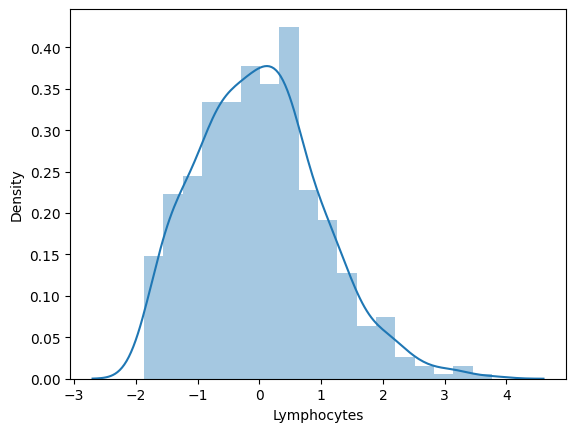

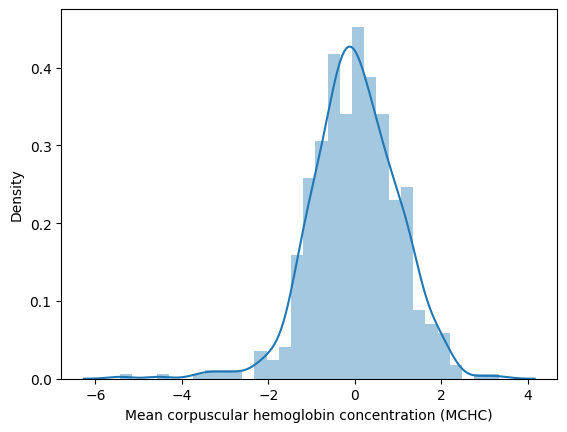

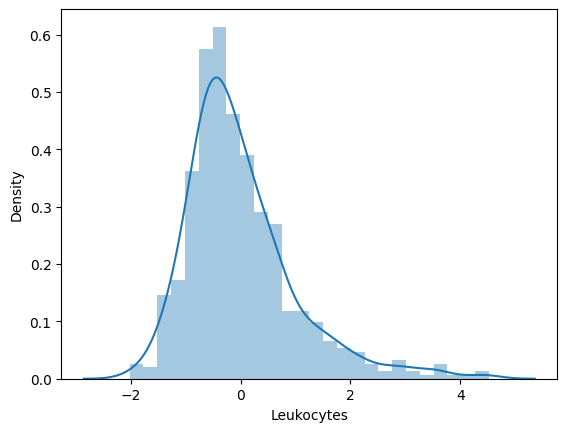

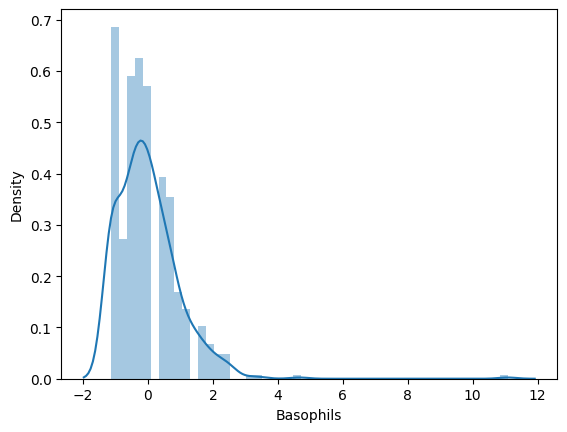

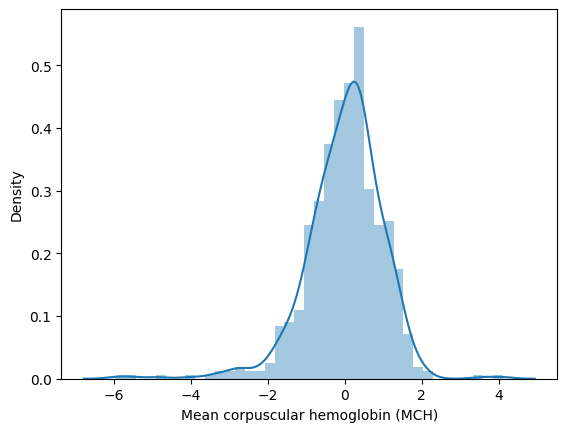

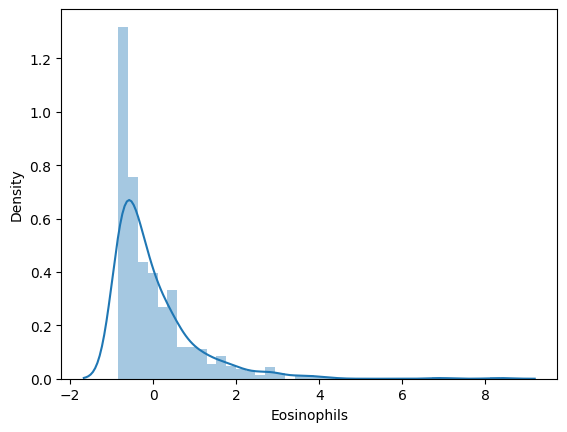

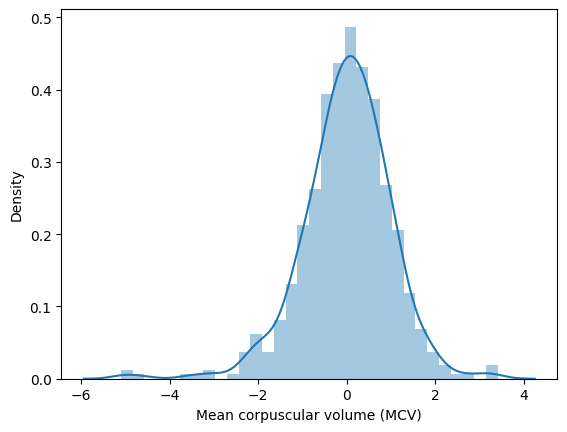

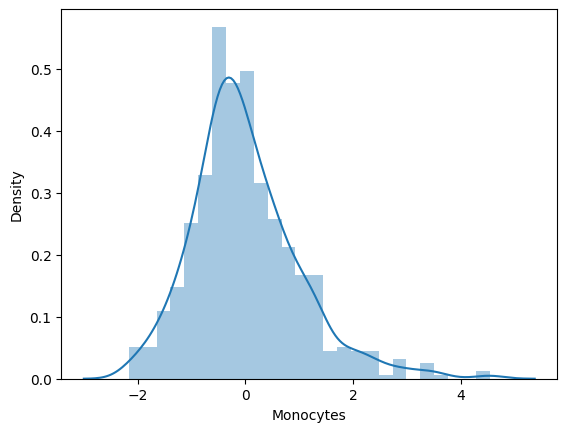

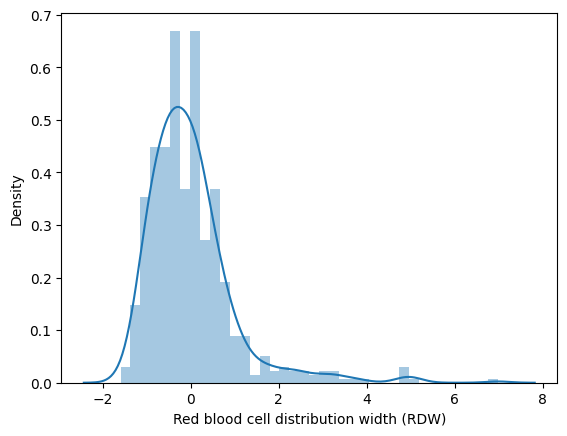

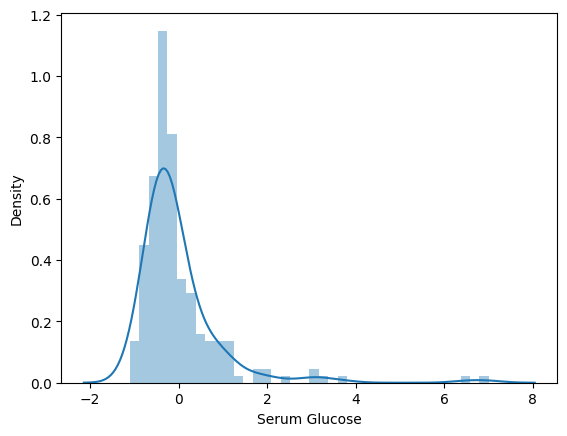

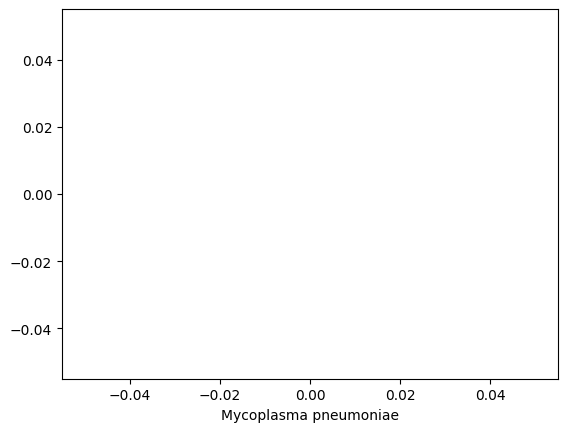

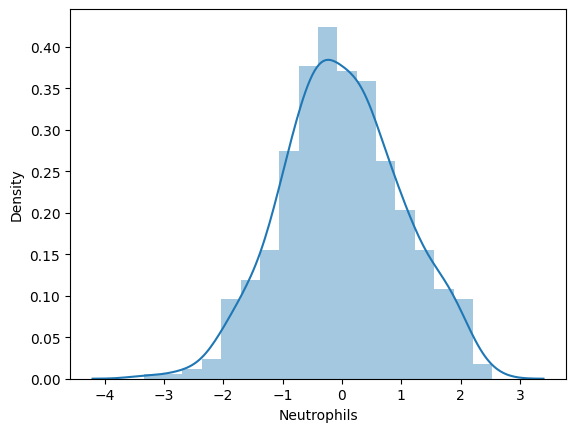

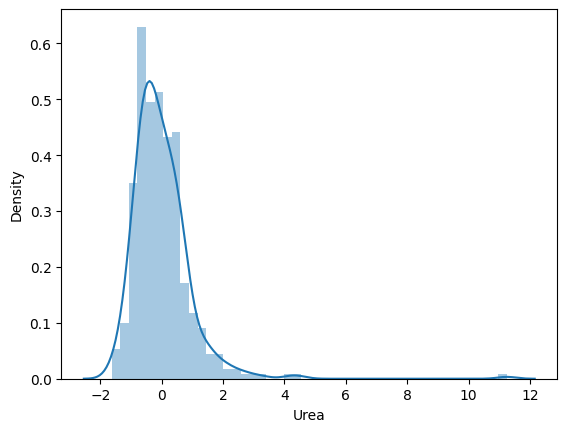

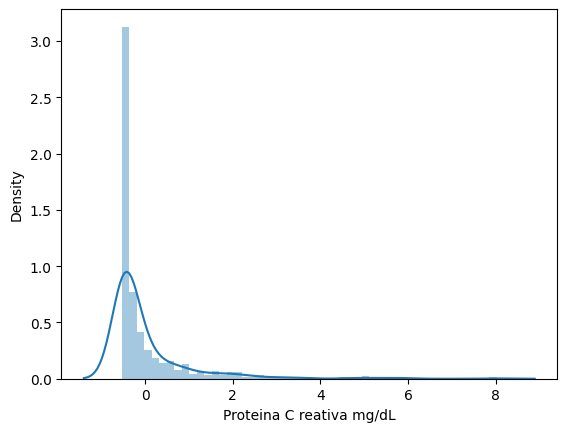

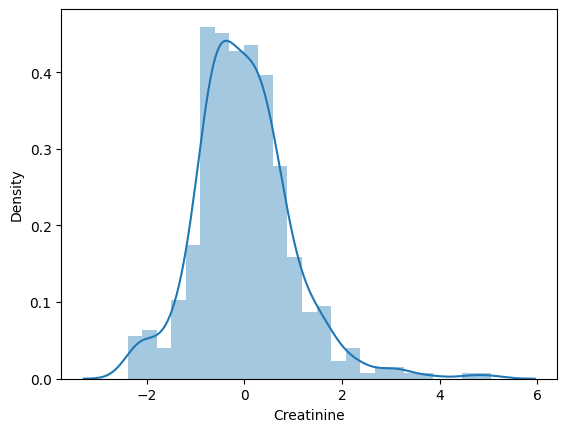

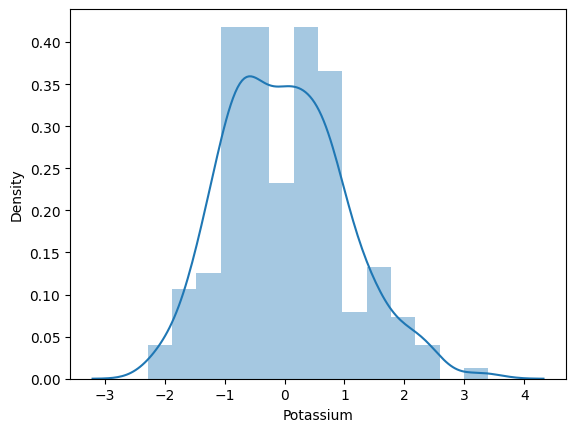

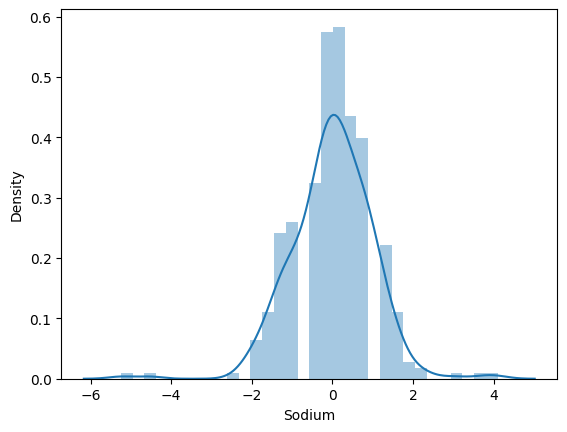

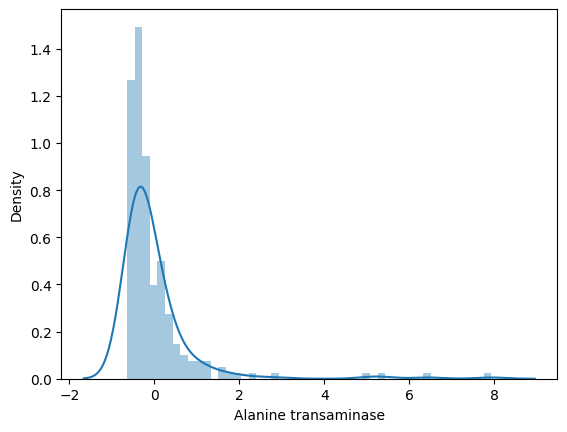

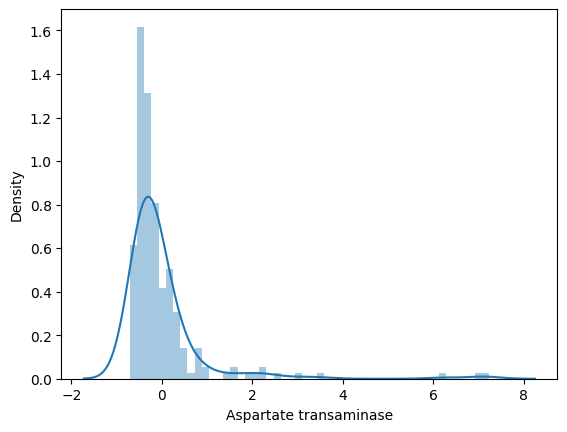

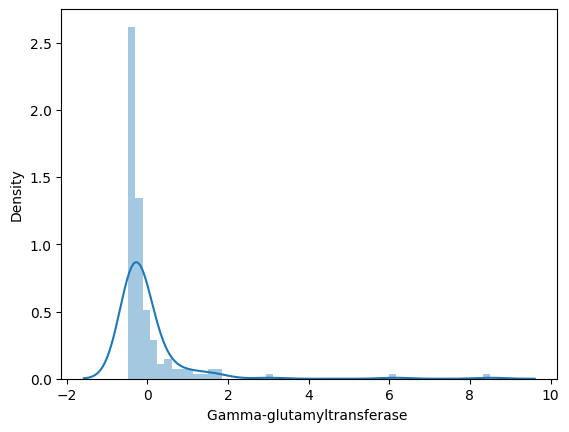

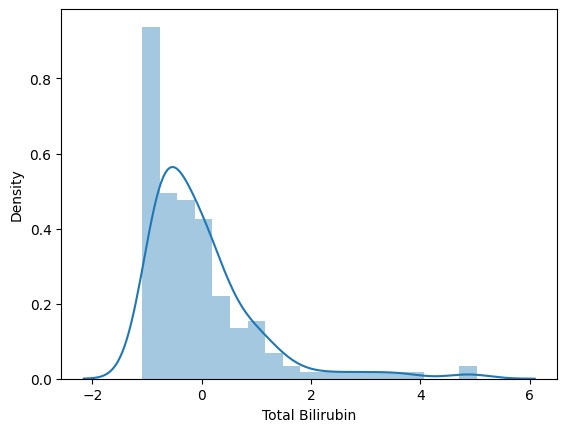

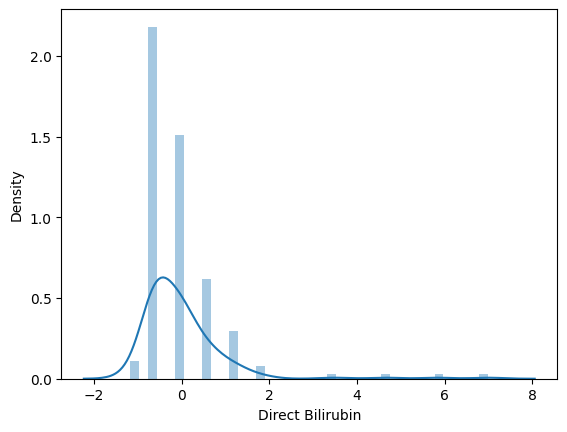

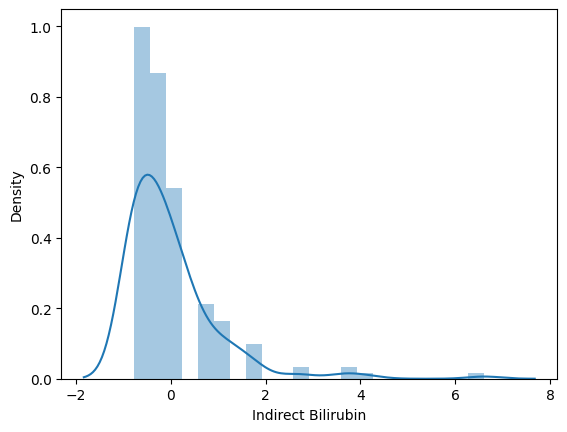

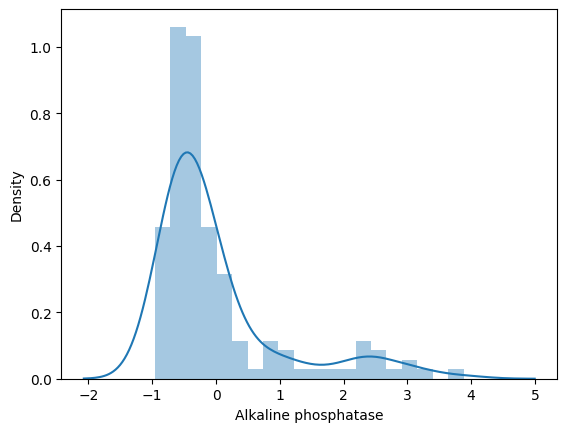

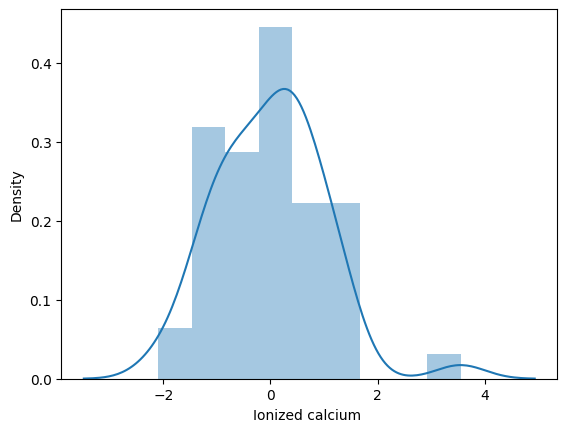

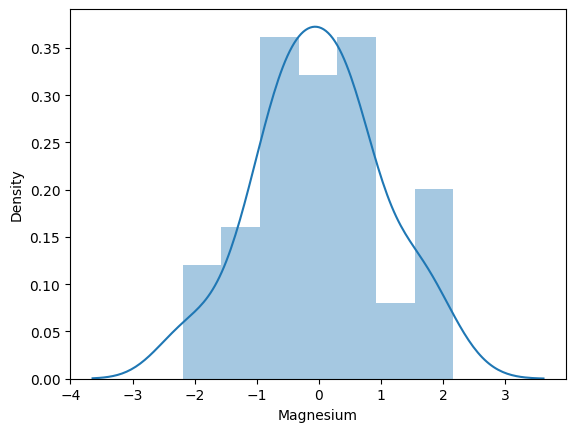

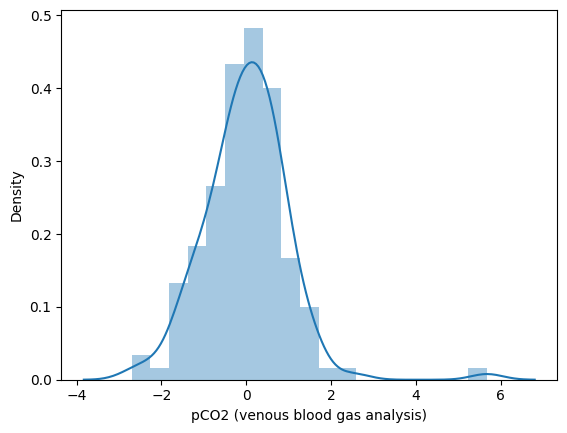

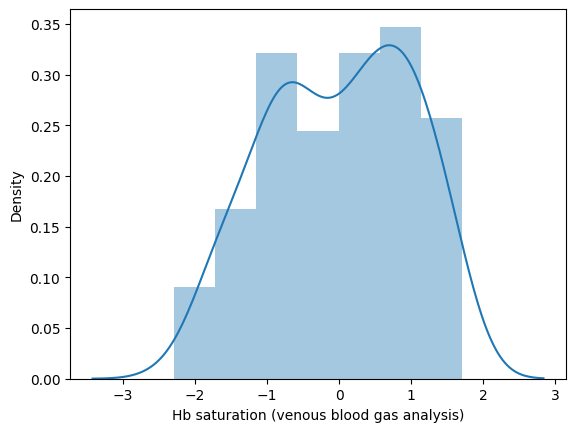

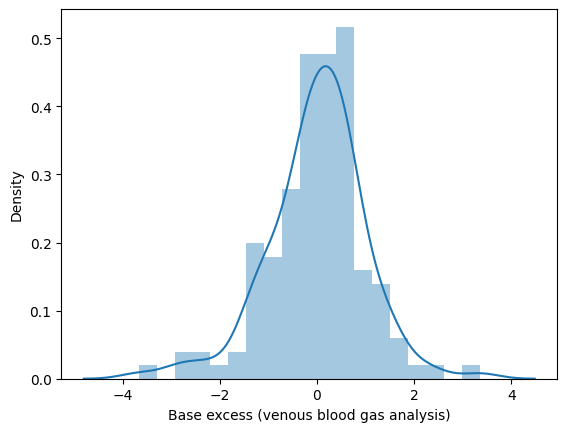

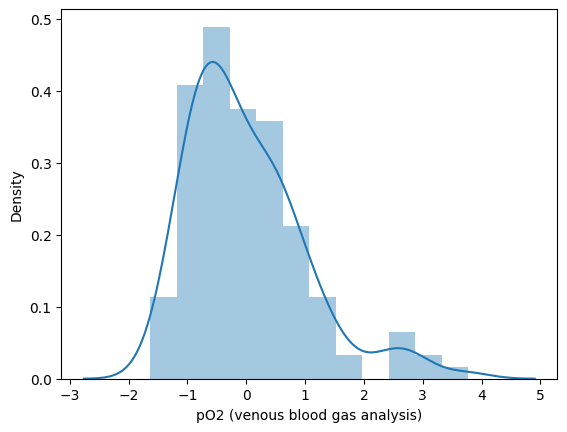

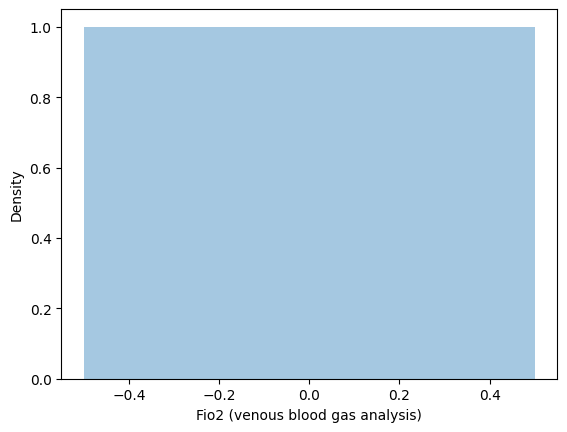

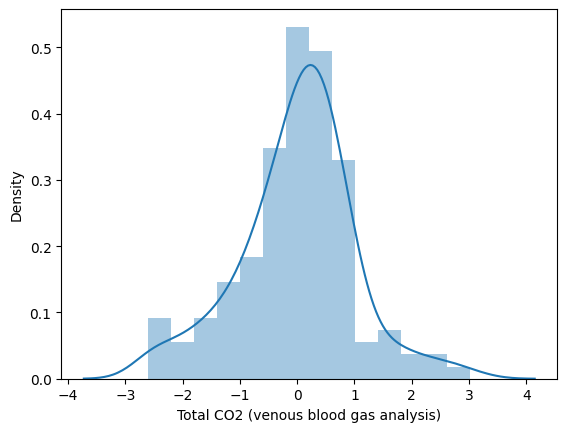

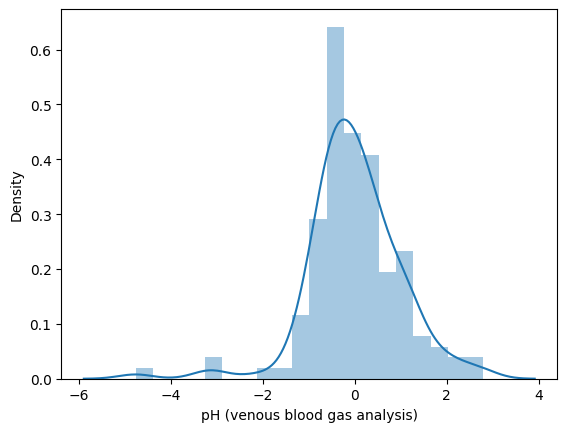

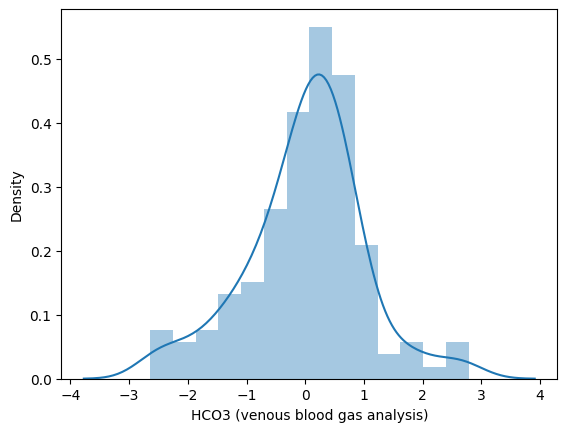

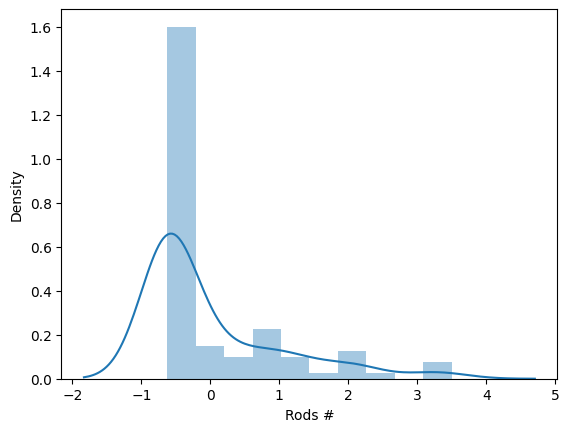

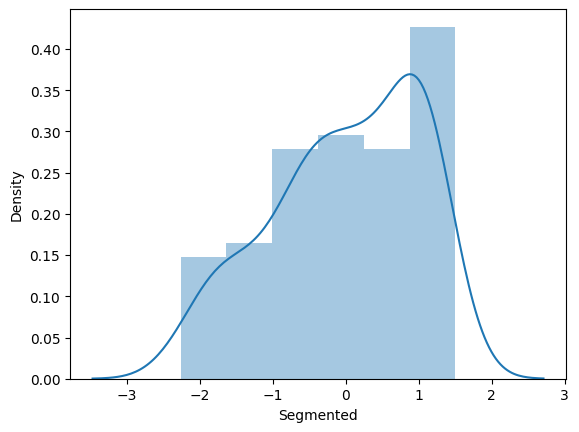

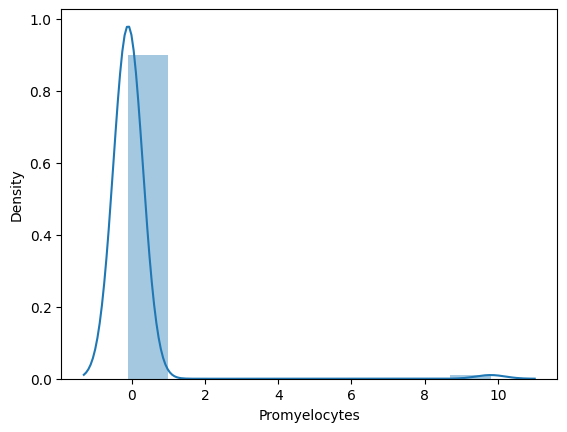

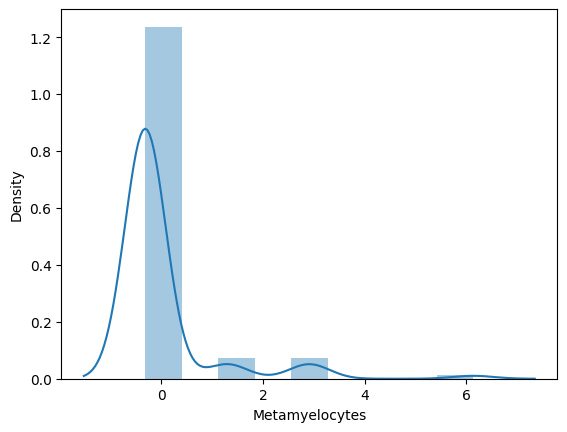

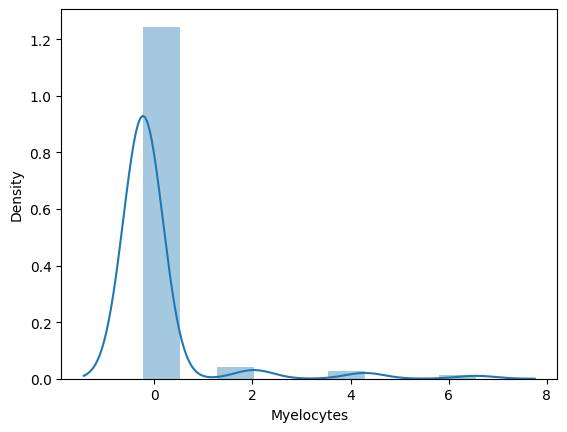

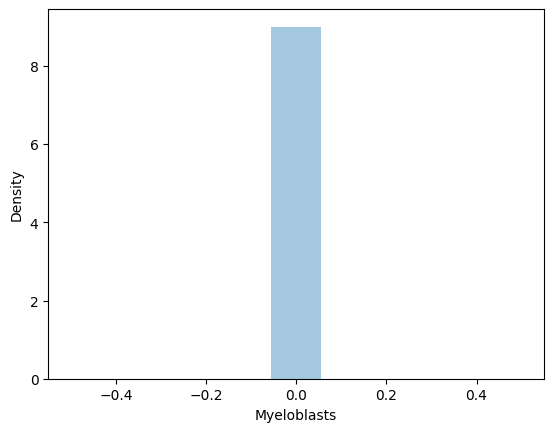

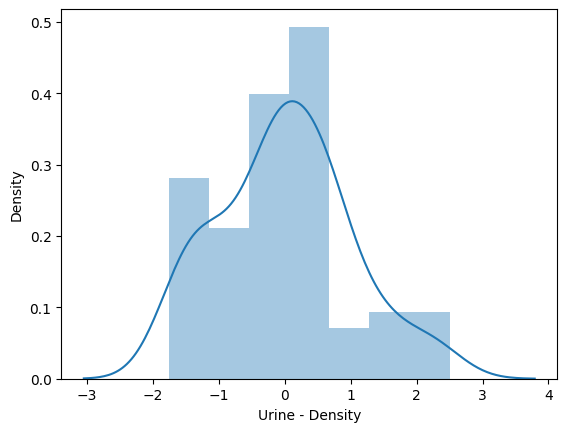

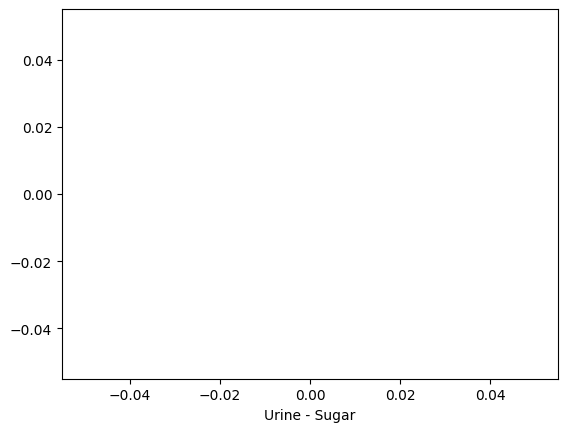

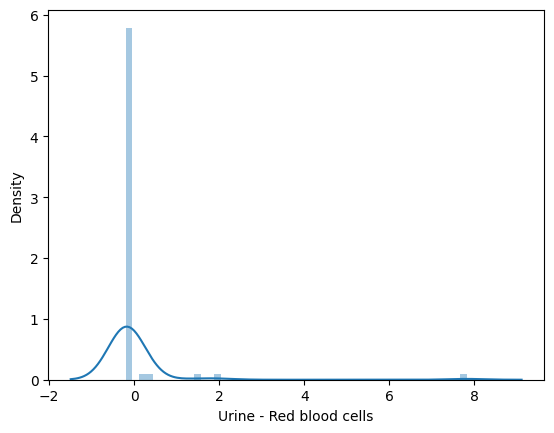

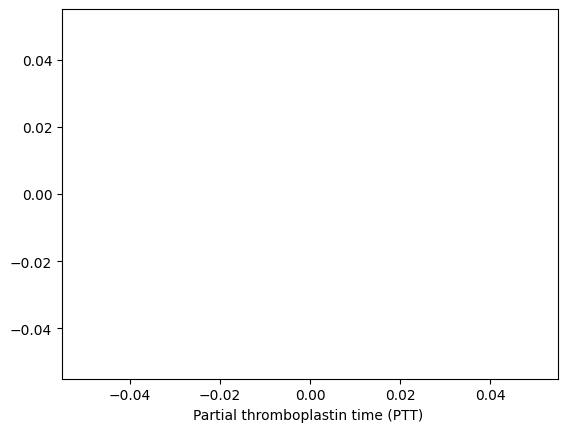

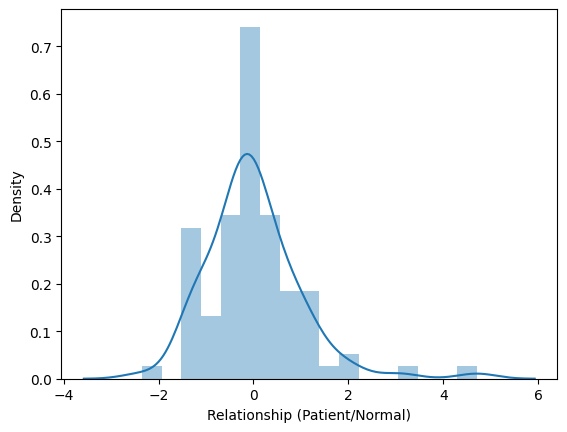

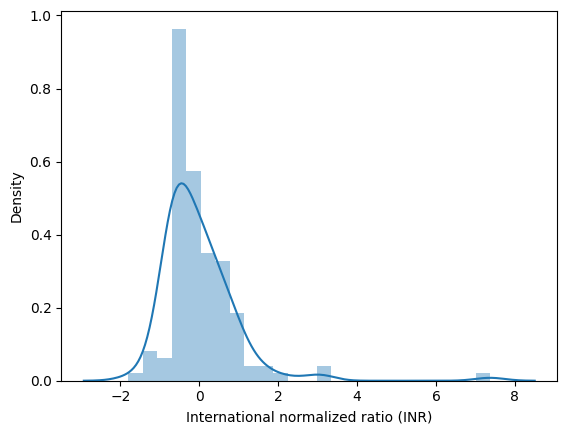

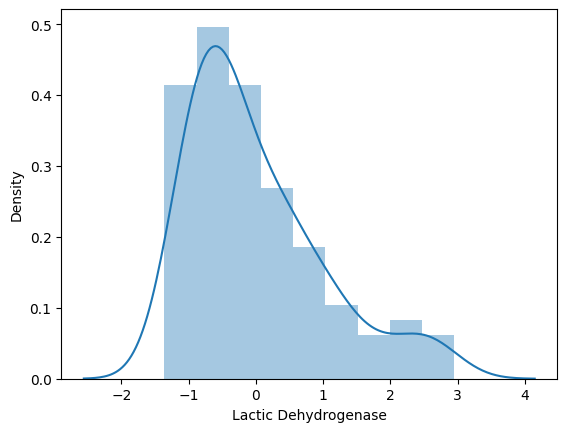

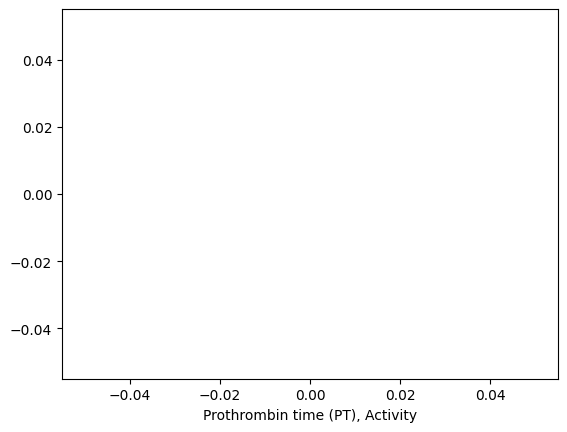

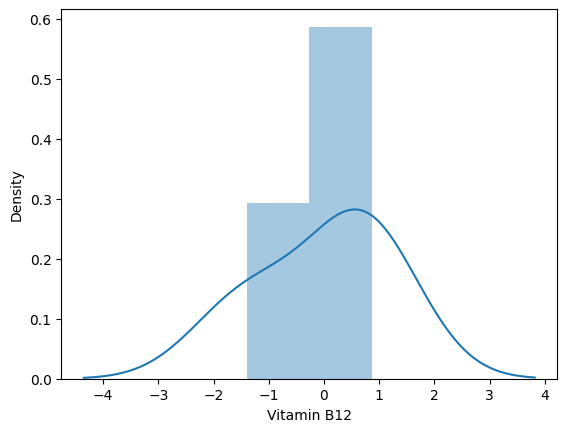

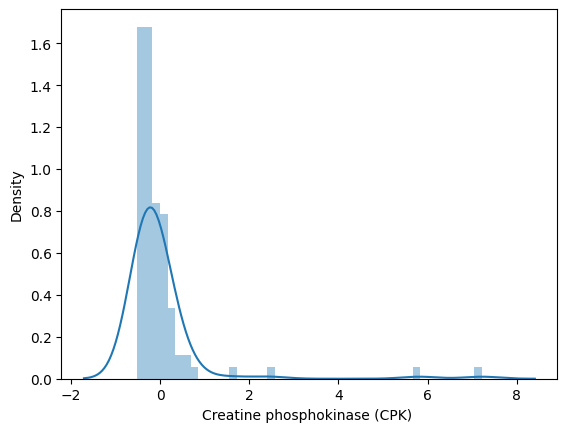

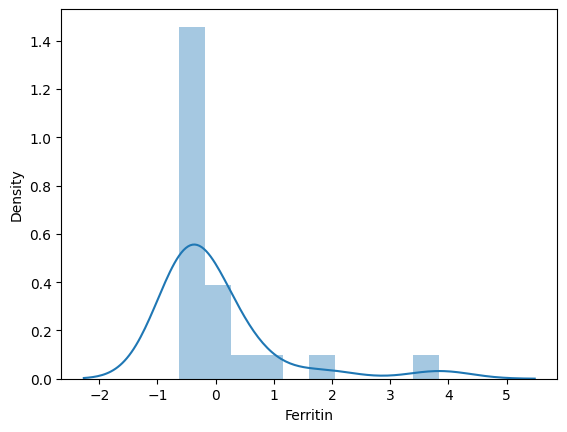

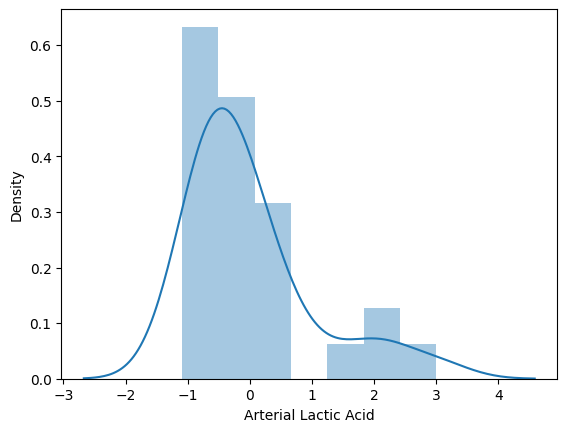

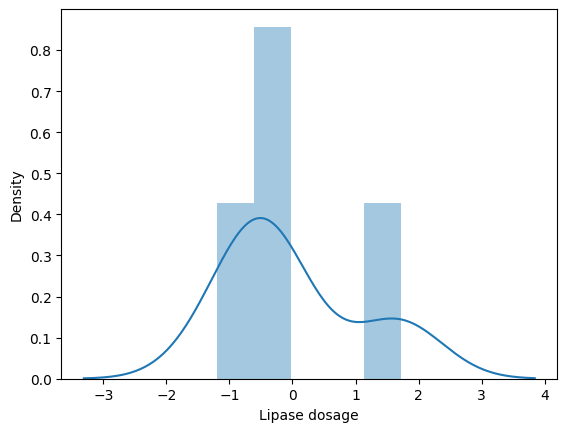

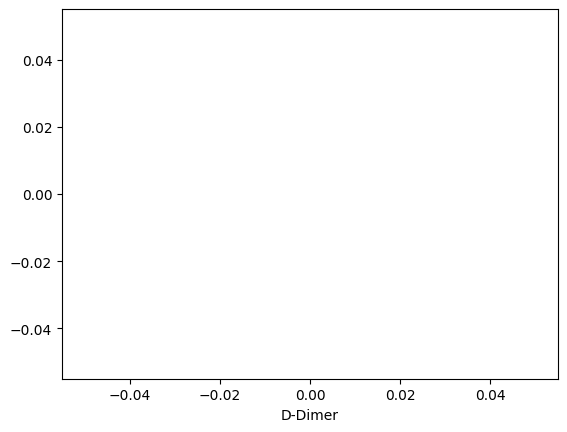

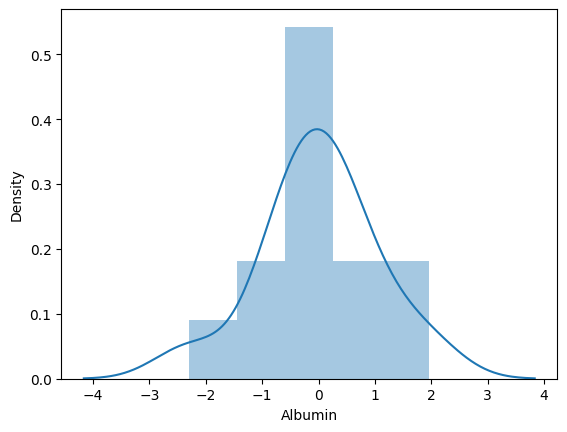

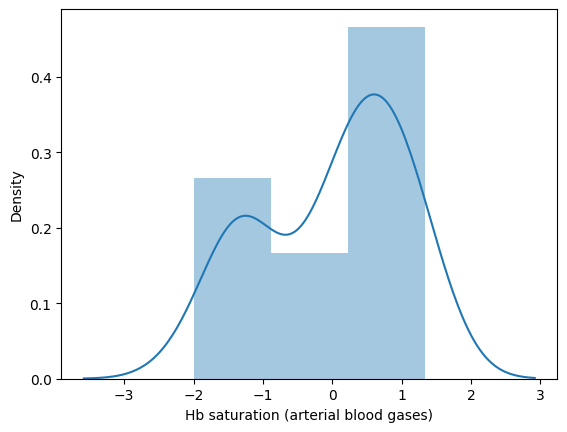

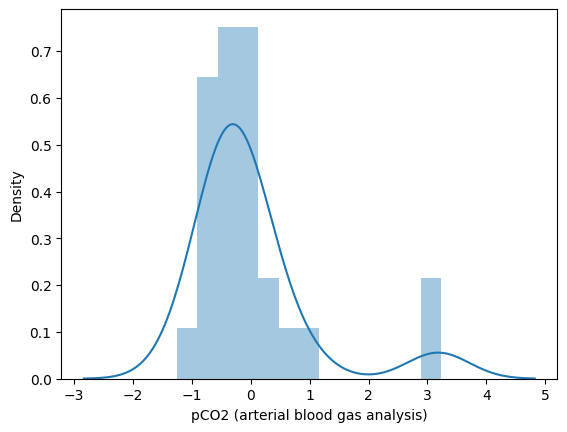

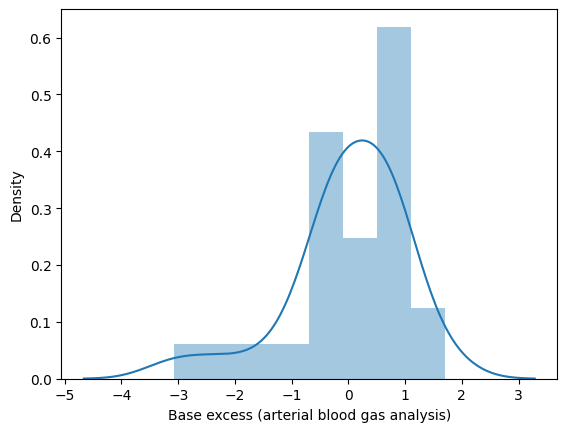

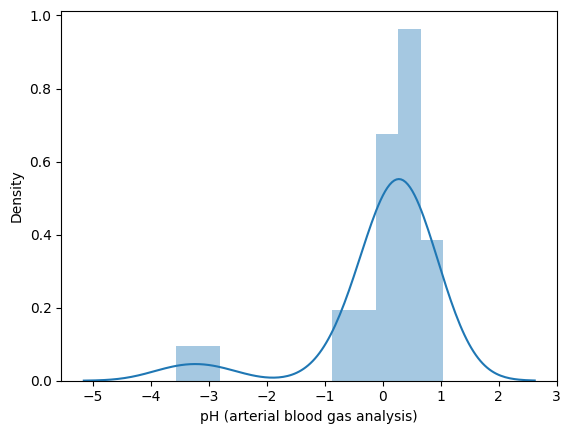

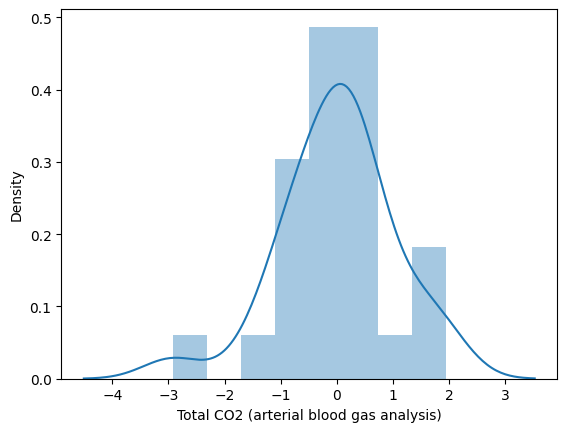

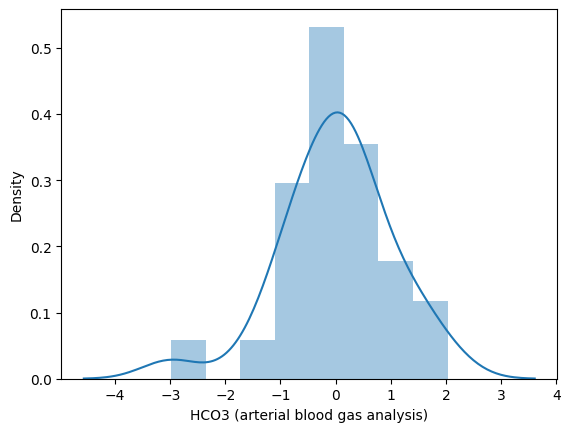

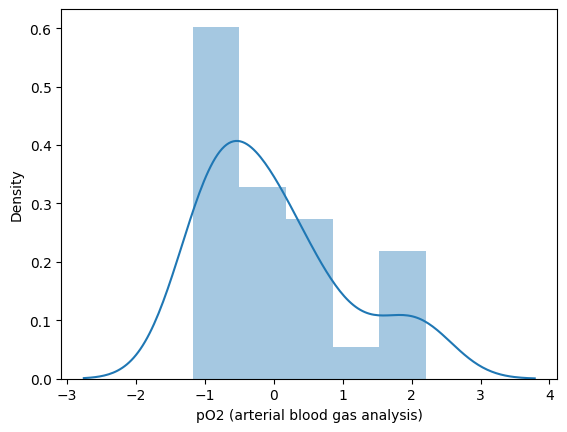

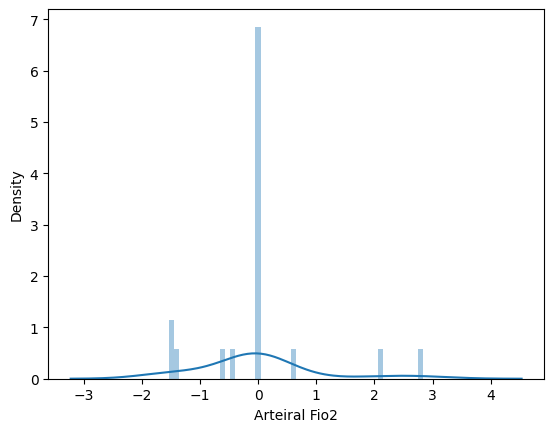

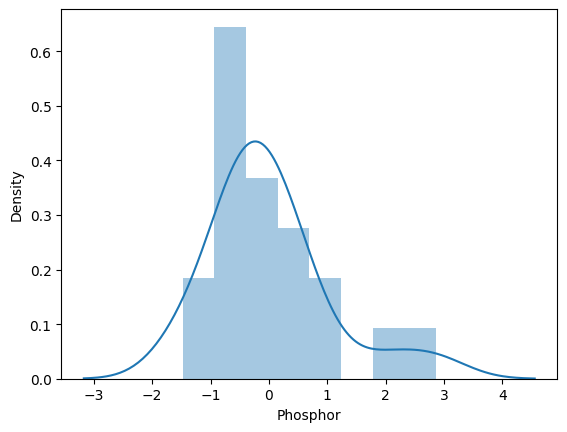

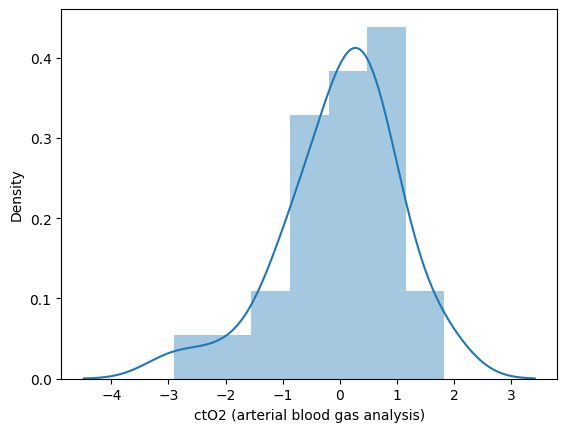

In [25]:
for col in df.select_dtypes('float'):
    plt.figure()
    sns.distplot(df[col])

<Axes: xlabel='Patient age quantile', ylabel='Density'>

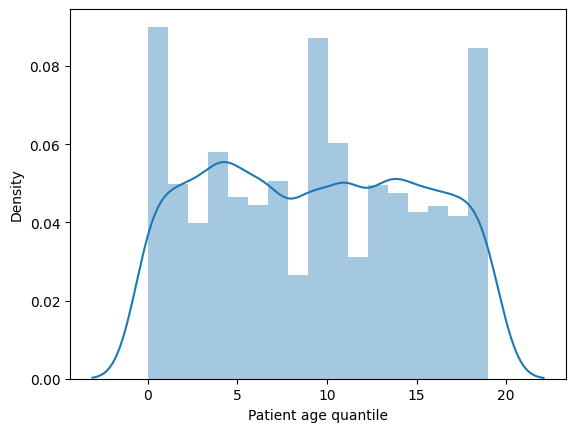

In [26]:
sns.distplot(df['Patient age quantile'])

## **Variables Qualitatives**

In [15]:
for col in df.select_dtypes('object'):
    print(f'{col :-<50}{df[col].unique()}')

SARS-Cov-2 exam result----------------------------['negative' 'positive']
Respiratory Syncytial Virus-----------------------[nan 'not_detected' 'detected']
Influenza A---------------------------------------[nan 'not_detected' 'detected']
Influenza B---------------------------------------[nan 'not_detected' 'detected']
Parainfluenza 1-----------------------------------[nan 'not_detected' 'detected']
CoronavirusNL63-----------------------------------[nan 'not_detected' 'detected']
Rhinovirus/Enterovirus----------------------------[nan 'detected' 'not_detected']
Coronavirus HKU1----------------------------------[nan 'not_detected' 'detected']
Parainfluenza 3-----------------------------------[nan 'not_detected' 'detected']
Chlamydophila pneumoniae--------------------------[nan 'not_detected' 'detected']
Adenovirus----------------------------------------[nan 'not_detected' 'detected']
Parainfluenza 4-----------------------------------[nan 'not_detected' 'detected']
Coronavirus229E---------

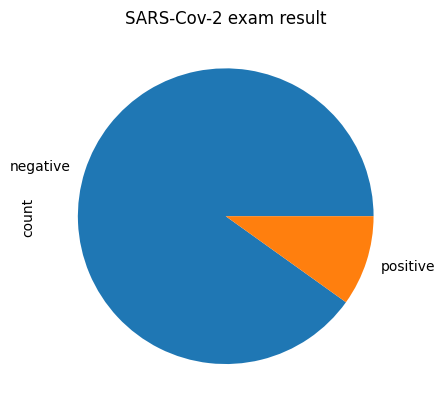

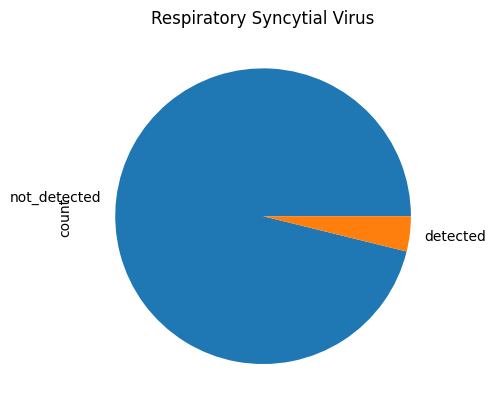

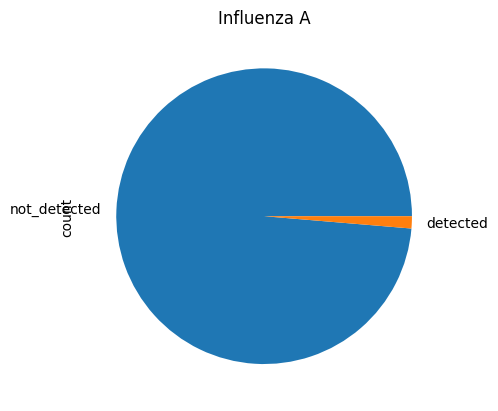

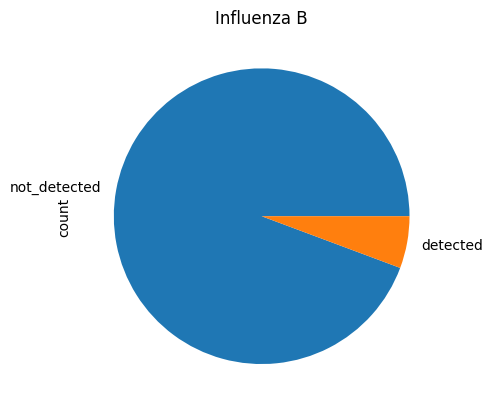

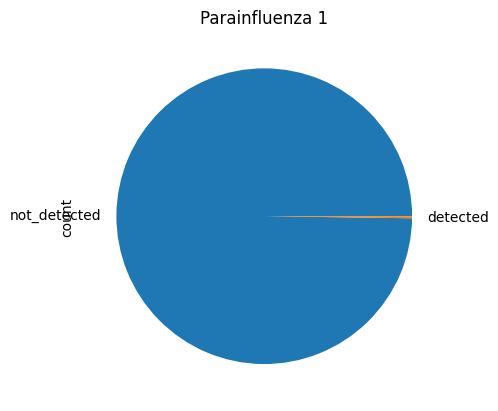

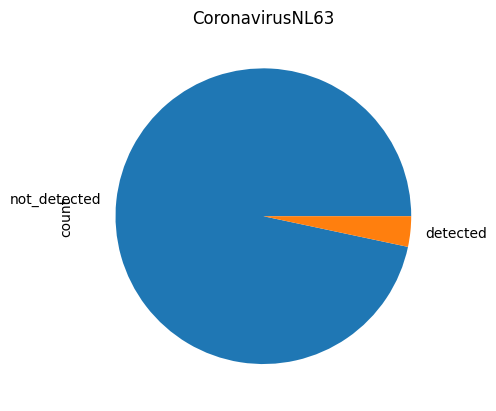

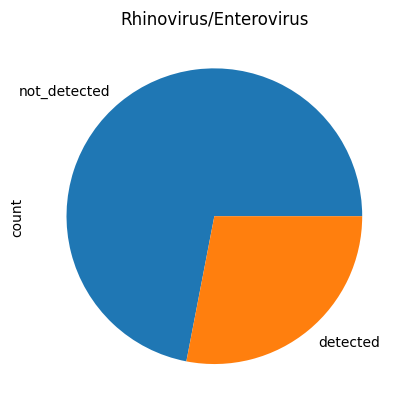

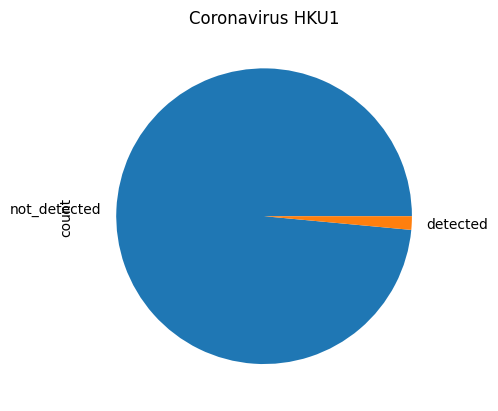

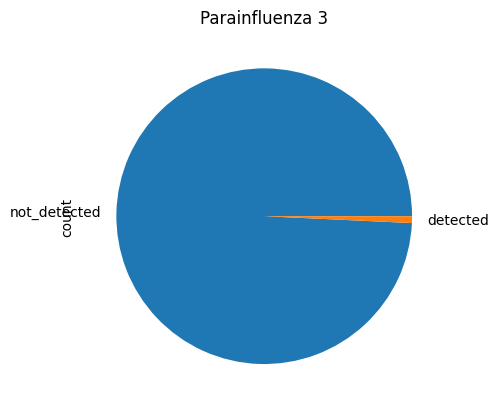

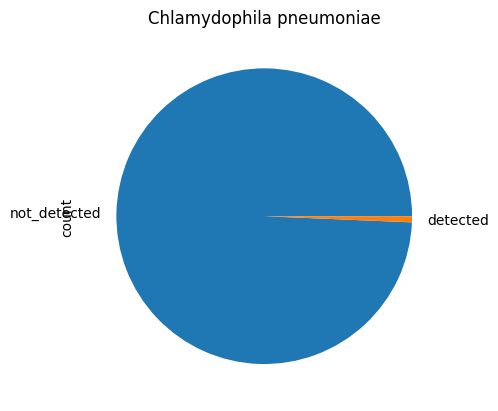

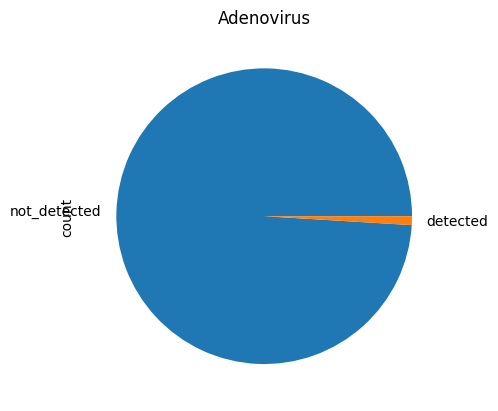

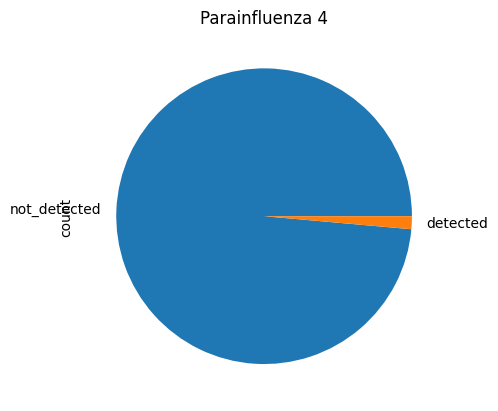

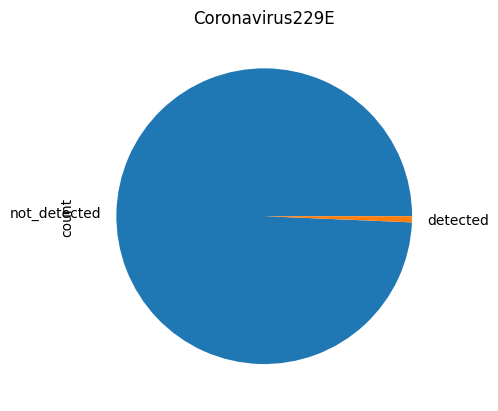

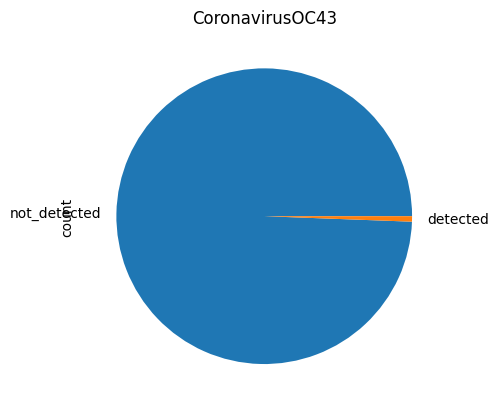

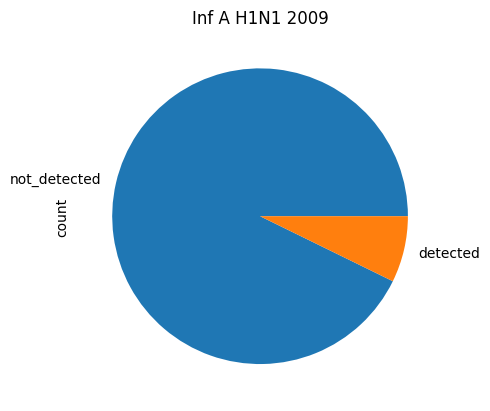

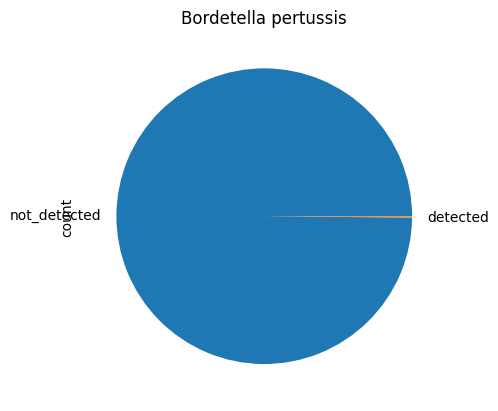

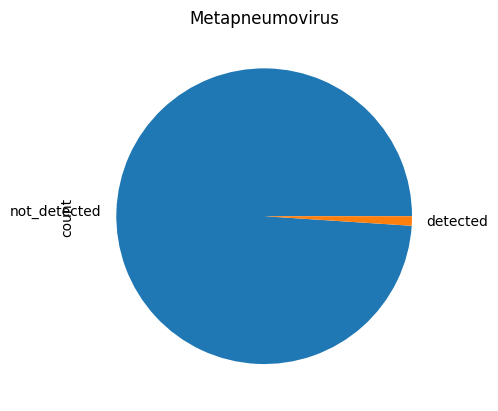

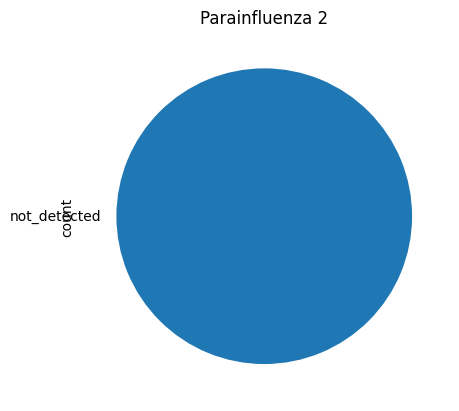

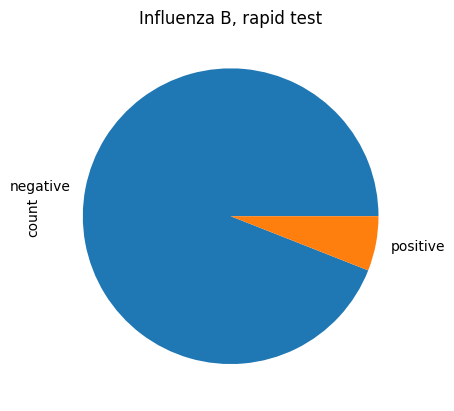

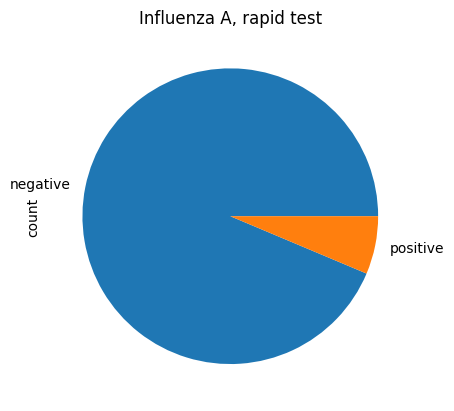

In [16]:
for col in df.select_dtypes('object'):
    plt.figure()
    df[col].value_counts().plot.pie()
    plt.title(col)

## **Relation Variables / Target**

### **Création de sous_ensemble positifs et négatifs**

In [20]:
positive_df=df[df[target_feature]=='positive']
negative_df=df[df[target_feature]=='negative']

### **Création des ensembles Blood et viral**

In [21]:
missing_rate=df.isna().sum()/df.shape[0]

blood_columns=df.columns[(missing_rate>0.88)&(missing_rate<0.9)]
viral_columns=df.columns[(missing_rate>0.75)&(missing_rate<0.88)]

### **Target / Blood**

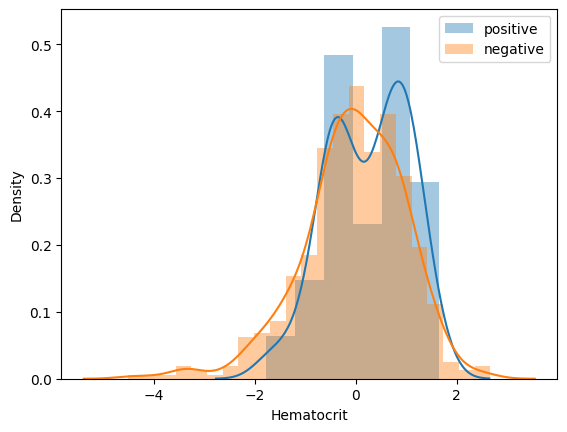

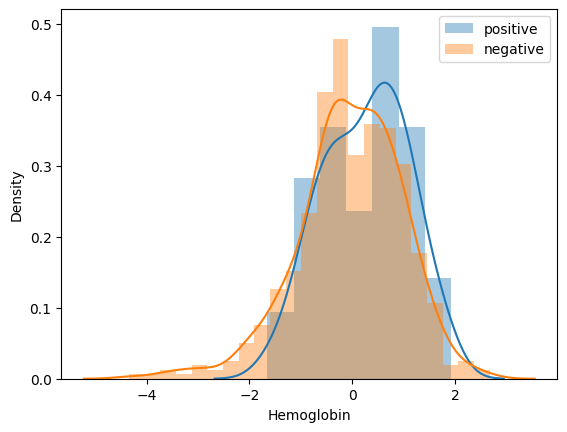

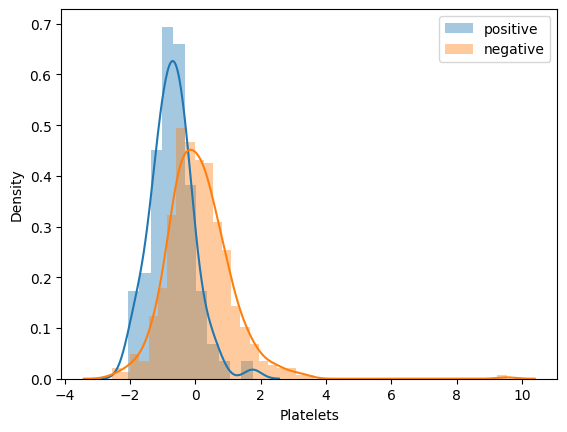

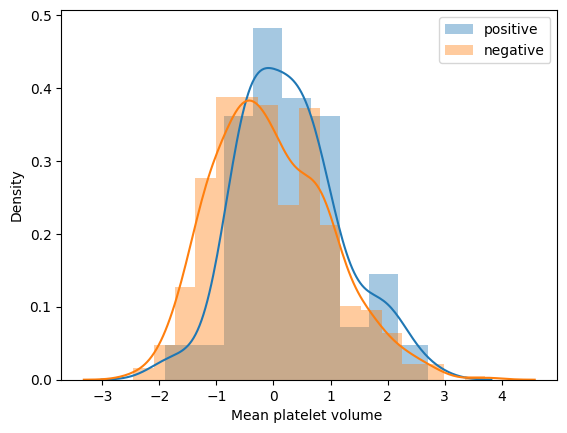

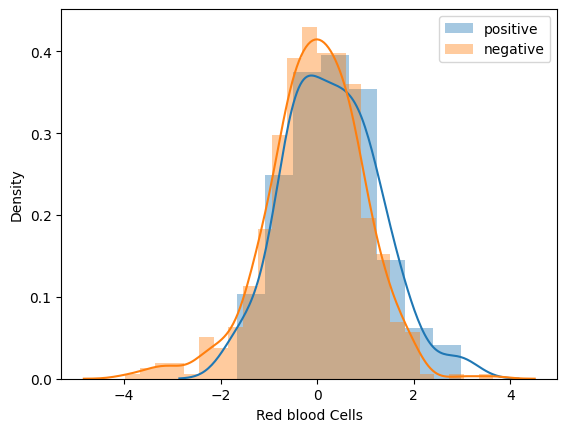

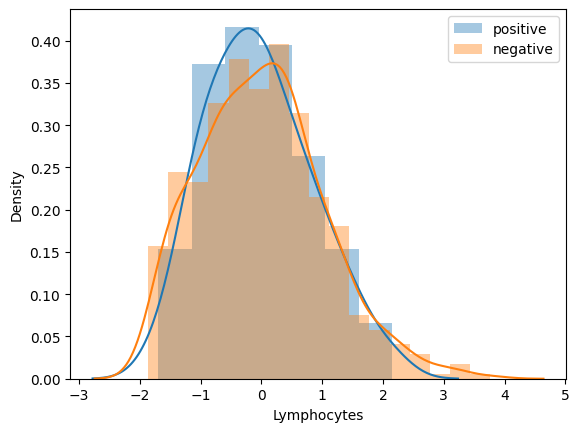

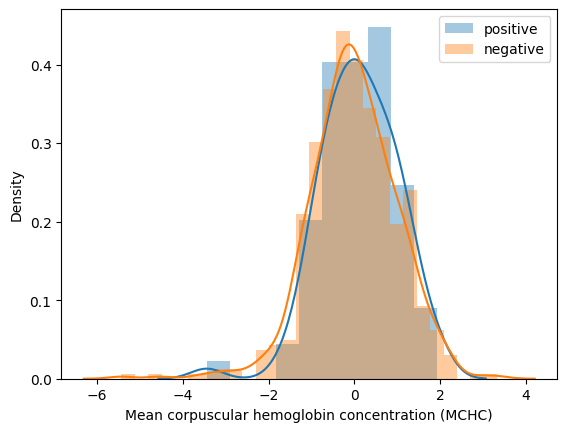

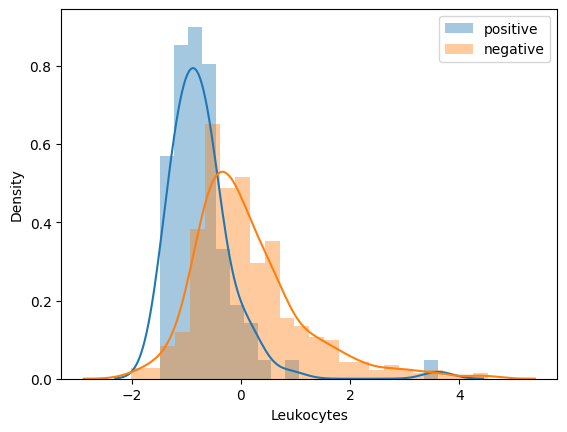

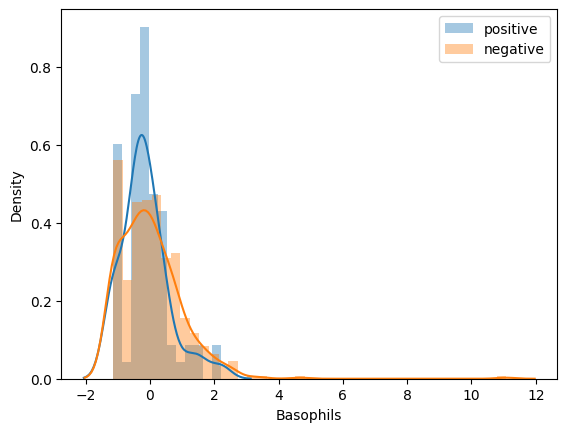

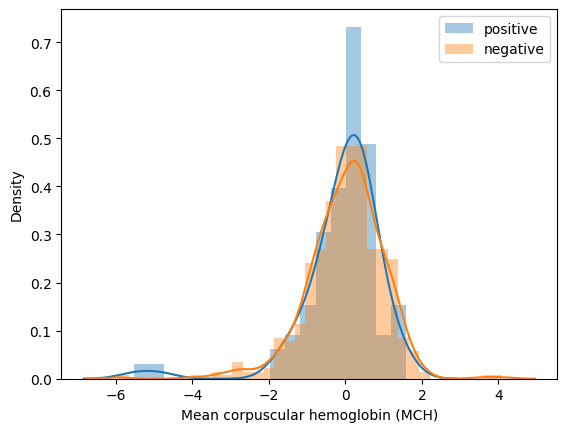

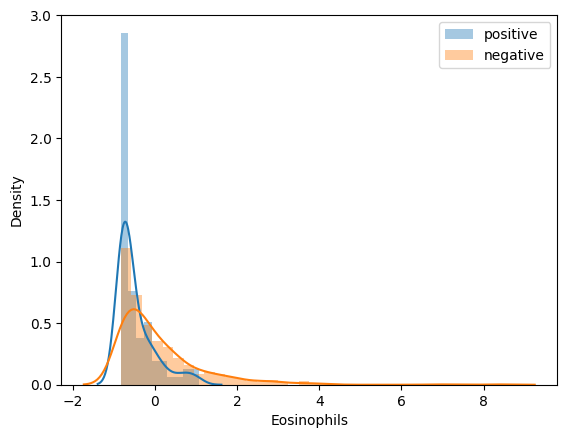

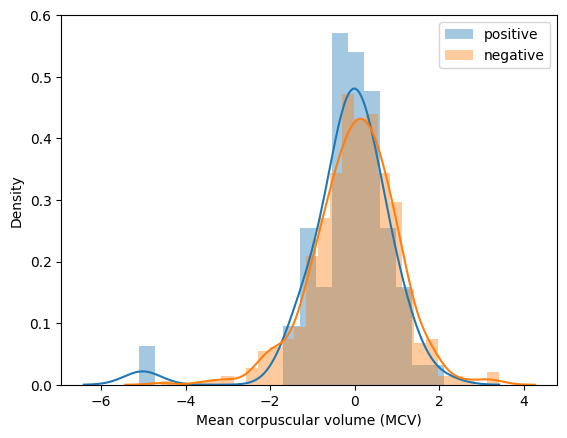

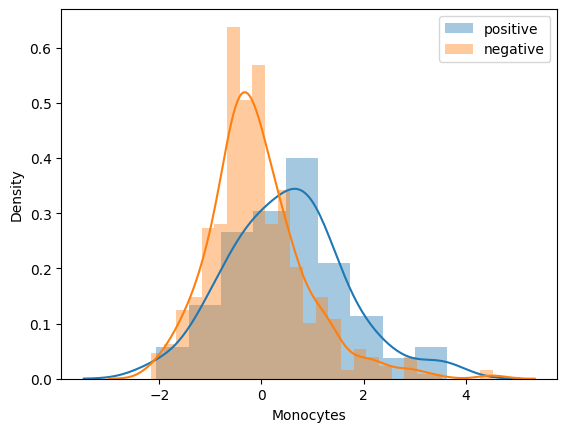

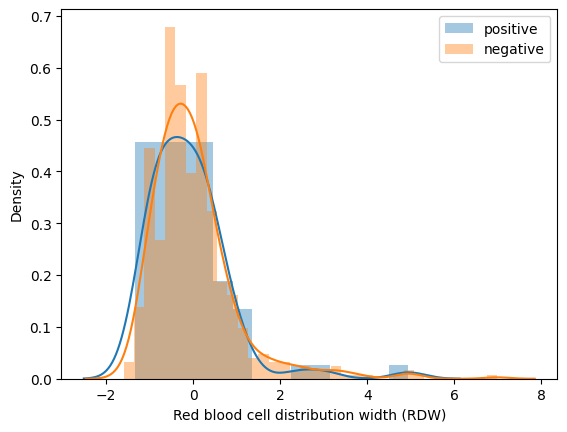

In [27]:
for col in blood_columns:
    plt.figure()
    sns.distplot(positive_df[col],label='positive')
    sns.distplot(negative_df[col],label='negative')
    plt.legend()

### **Relation target / age**

<Axes: xlabel='Patient age quantile', ylabel='count'>

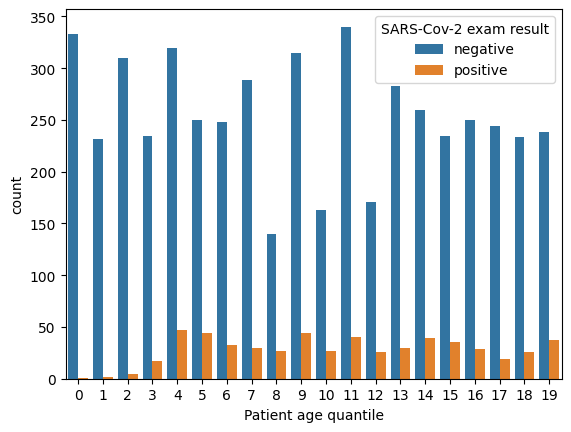

In [28]:
sns.countplot(x='Patient age quantile',hue=target_feature,data=df)

### **Relation Target / Viral**

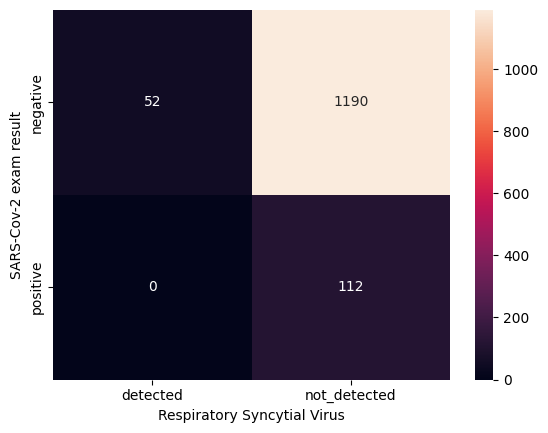

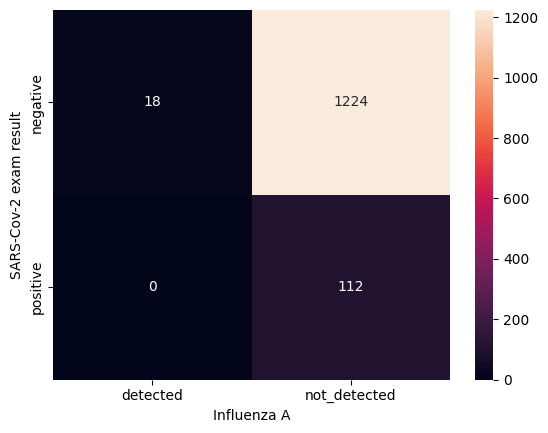

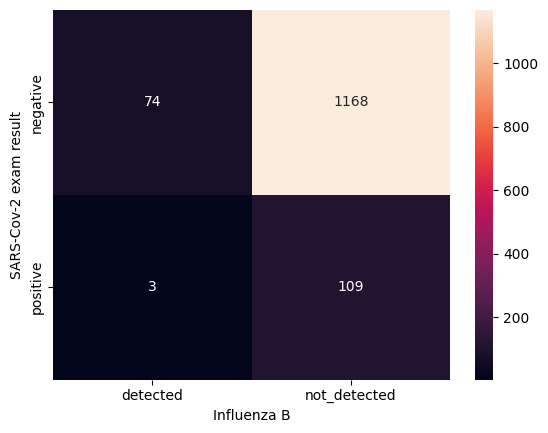

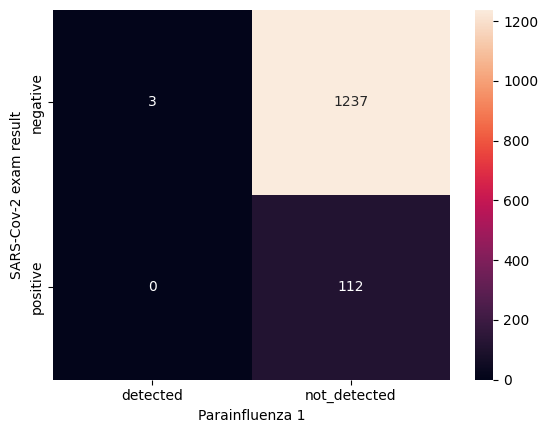

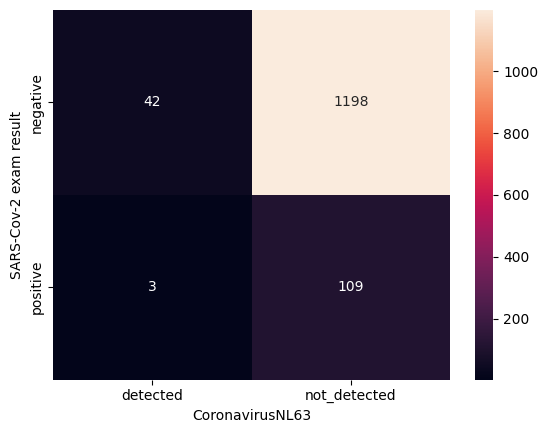

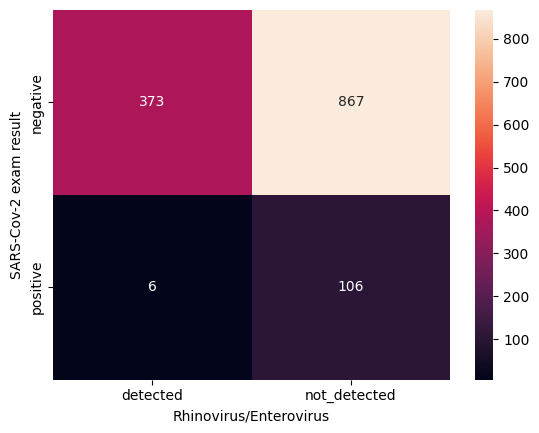

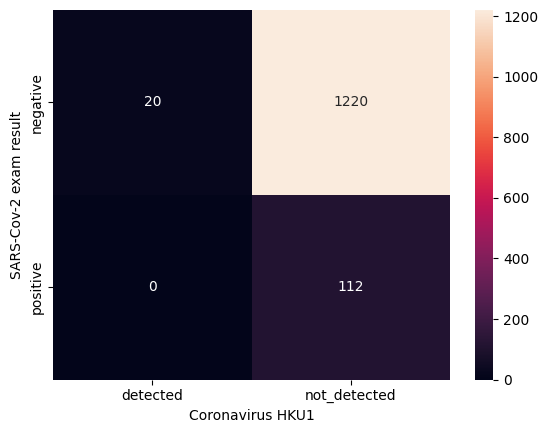

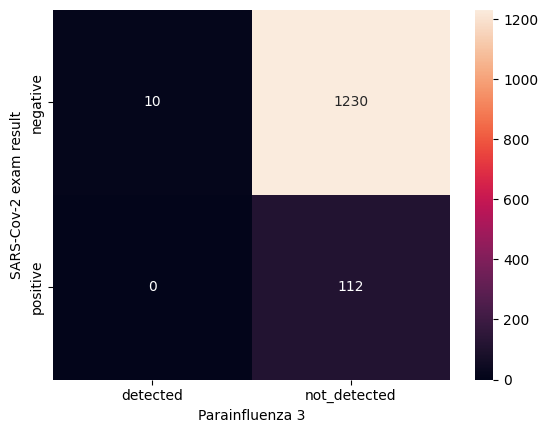

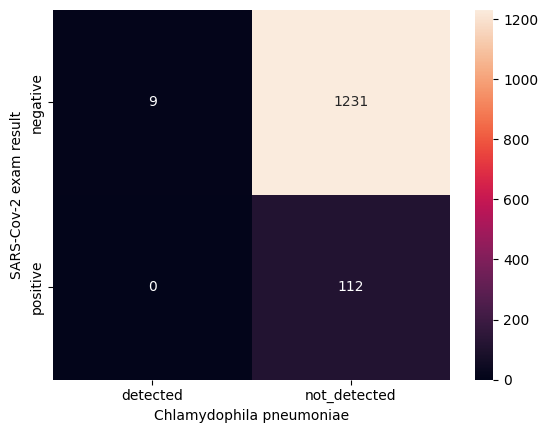

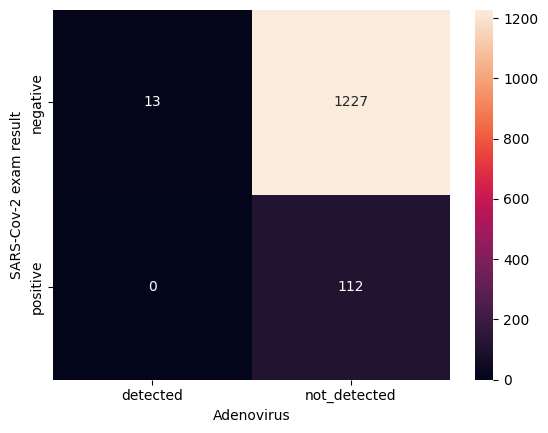

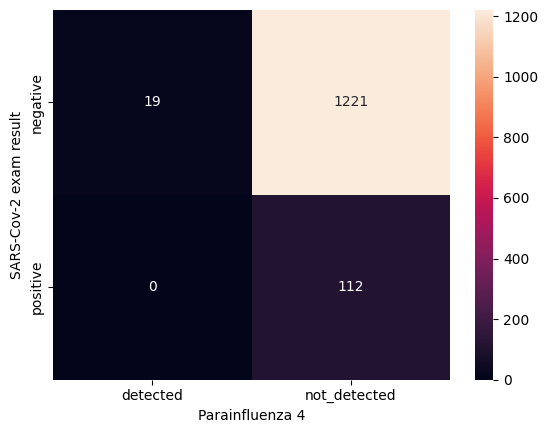

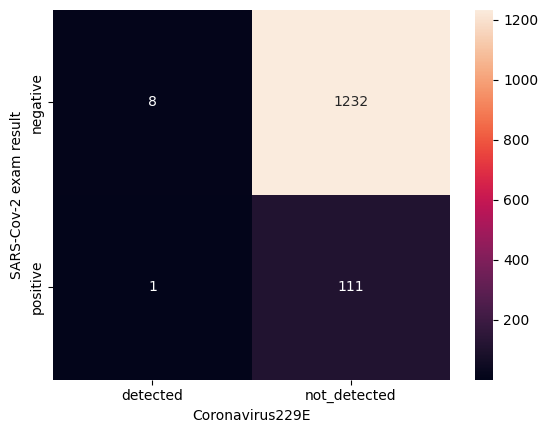

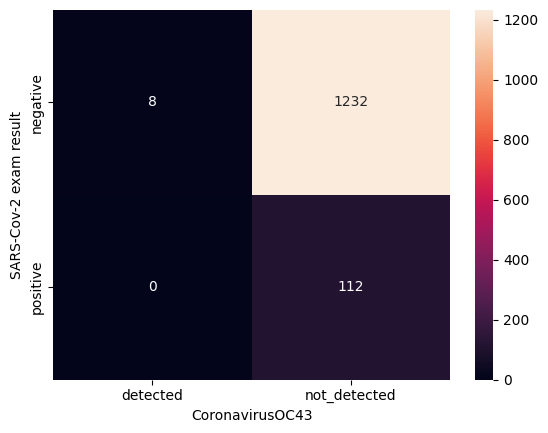

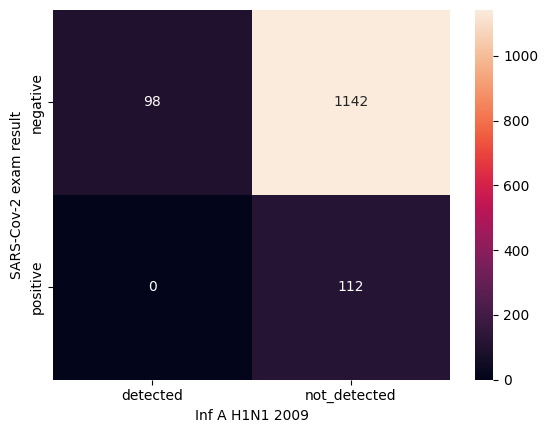

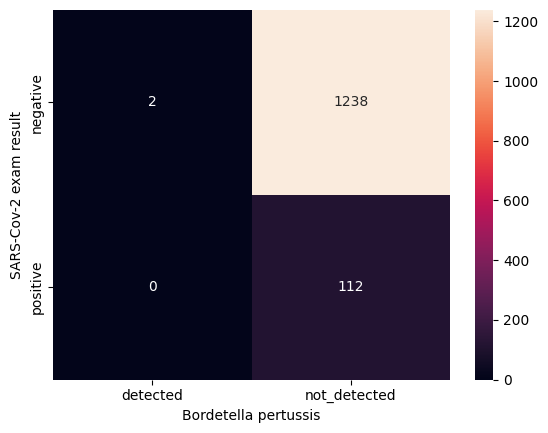

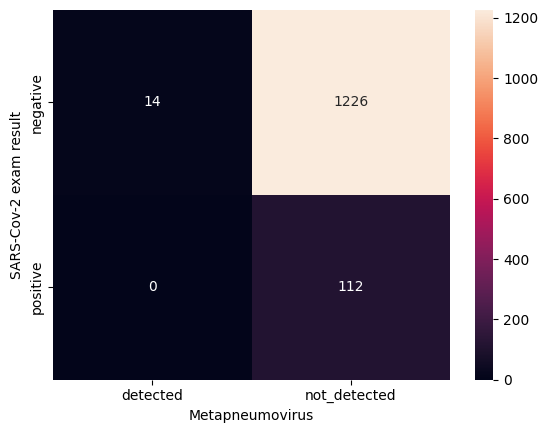

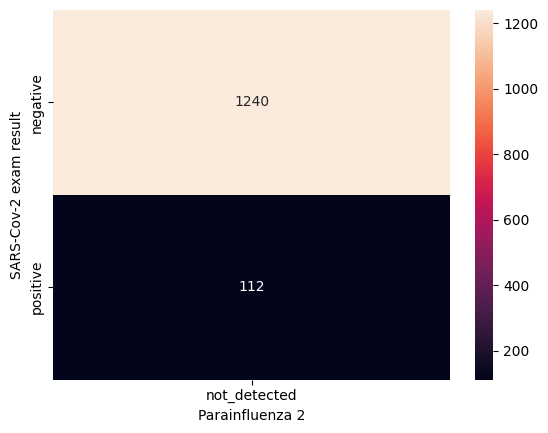

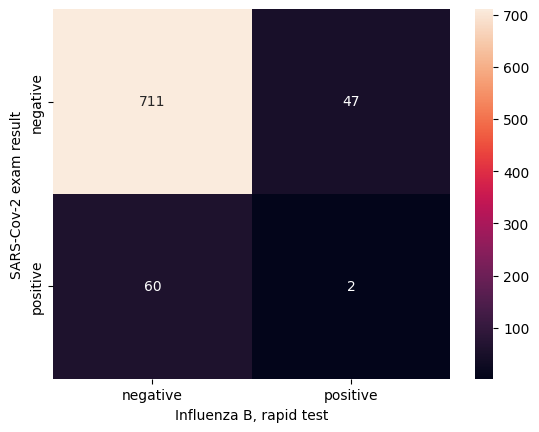

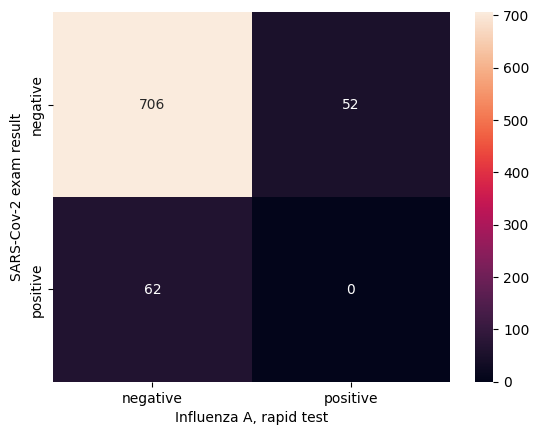

In [29]:
for col in viral_columns:
    plt.figure()
    sns.heatmap(pd.crosstab(df[target_feature],df[col]),annot=True,fmt='d')

 # 2. bis Analyse plus détaillée
 * **Relation Variables / Variables :**
    * **Blood_data / Blood_data** : certaines variables sont très corrélées: +0.9 (à surveiller plus tard)
    * **Blood_data / age** : très faible corelation entre age et taux sanguin
    * **viral / viral** : influenza rapid test donne de mauvais résultats, il faudra peut-être l'enlever
    * **relation Viral / blood data** : les taux sanguins entre malades et covid sont différents
    * **relation hospitalisation / viral** :
    * **relation hospitalisation / blood** :intéressant dans le cas où on devrait prédire dans quel service un patient devrait aller

* **NaN Analyse** : viral : 1350(92/8%), blood : 600(87/13%), both 90

* **Hypothèses nulles (H0) :**
    * les individus covid ont des taux de Leucocytes, Monocytes et Platelets significativement différents
      * H0= les taux moyens sont EGAUX chez les individus positifs et négatifs
      * Hypothèse rejetée pour Platelets et Leukocytes
    * les individus atteints d'une quelconque maladie ont des taux significativement différents

## **Relation Variables / Variables**

### **Relations Taux sanguin**

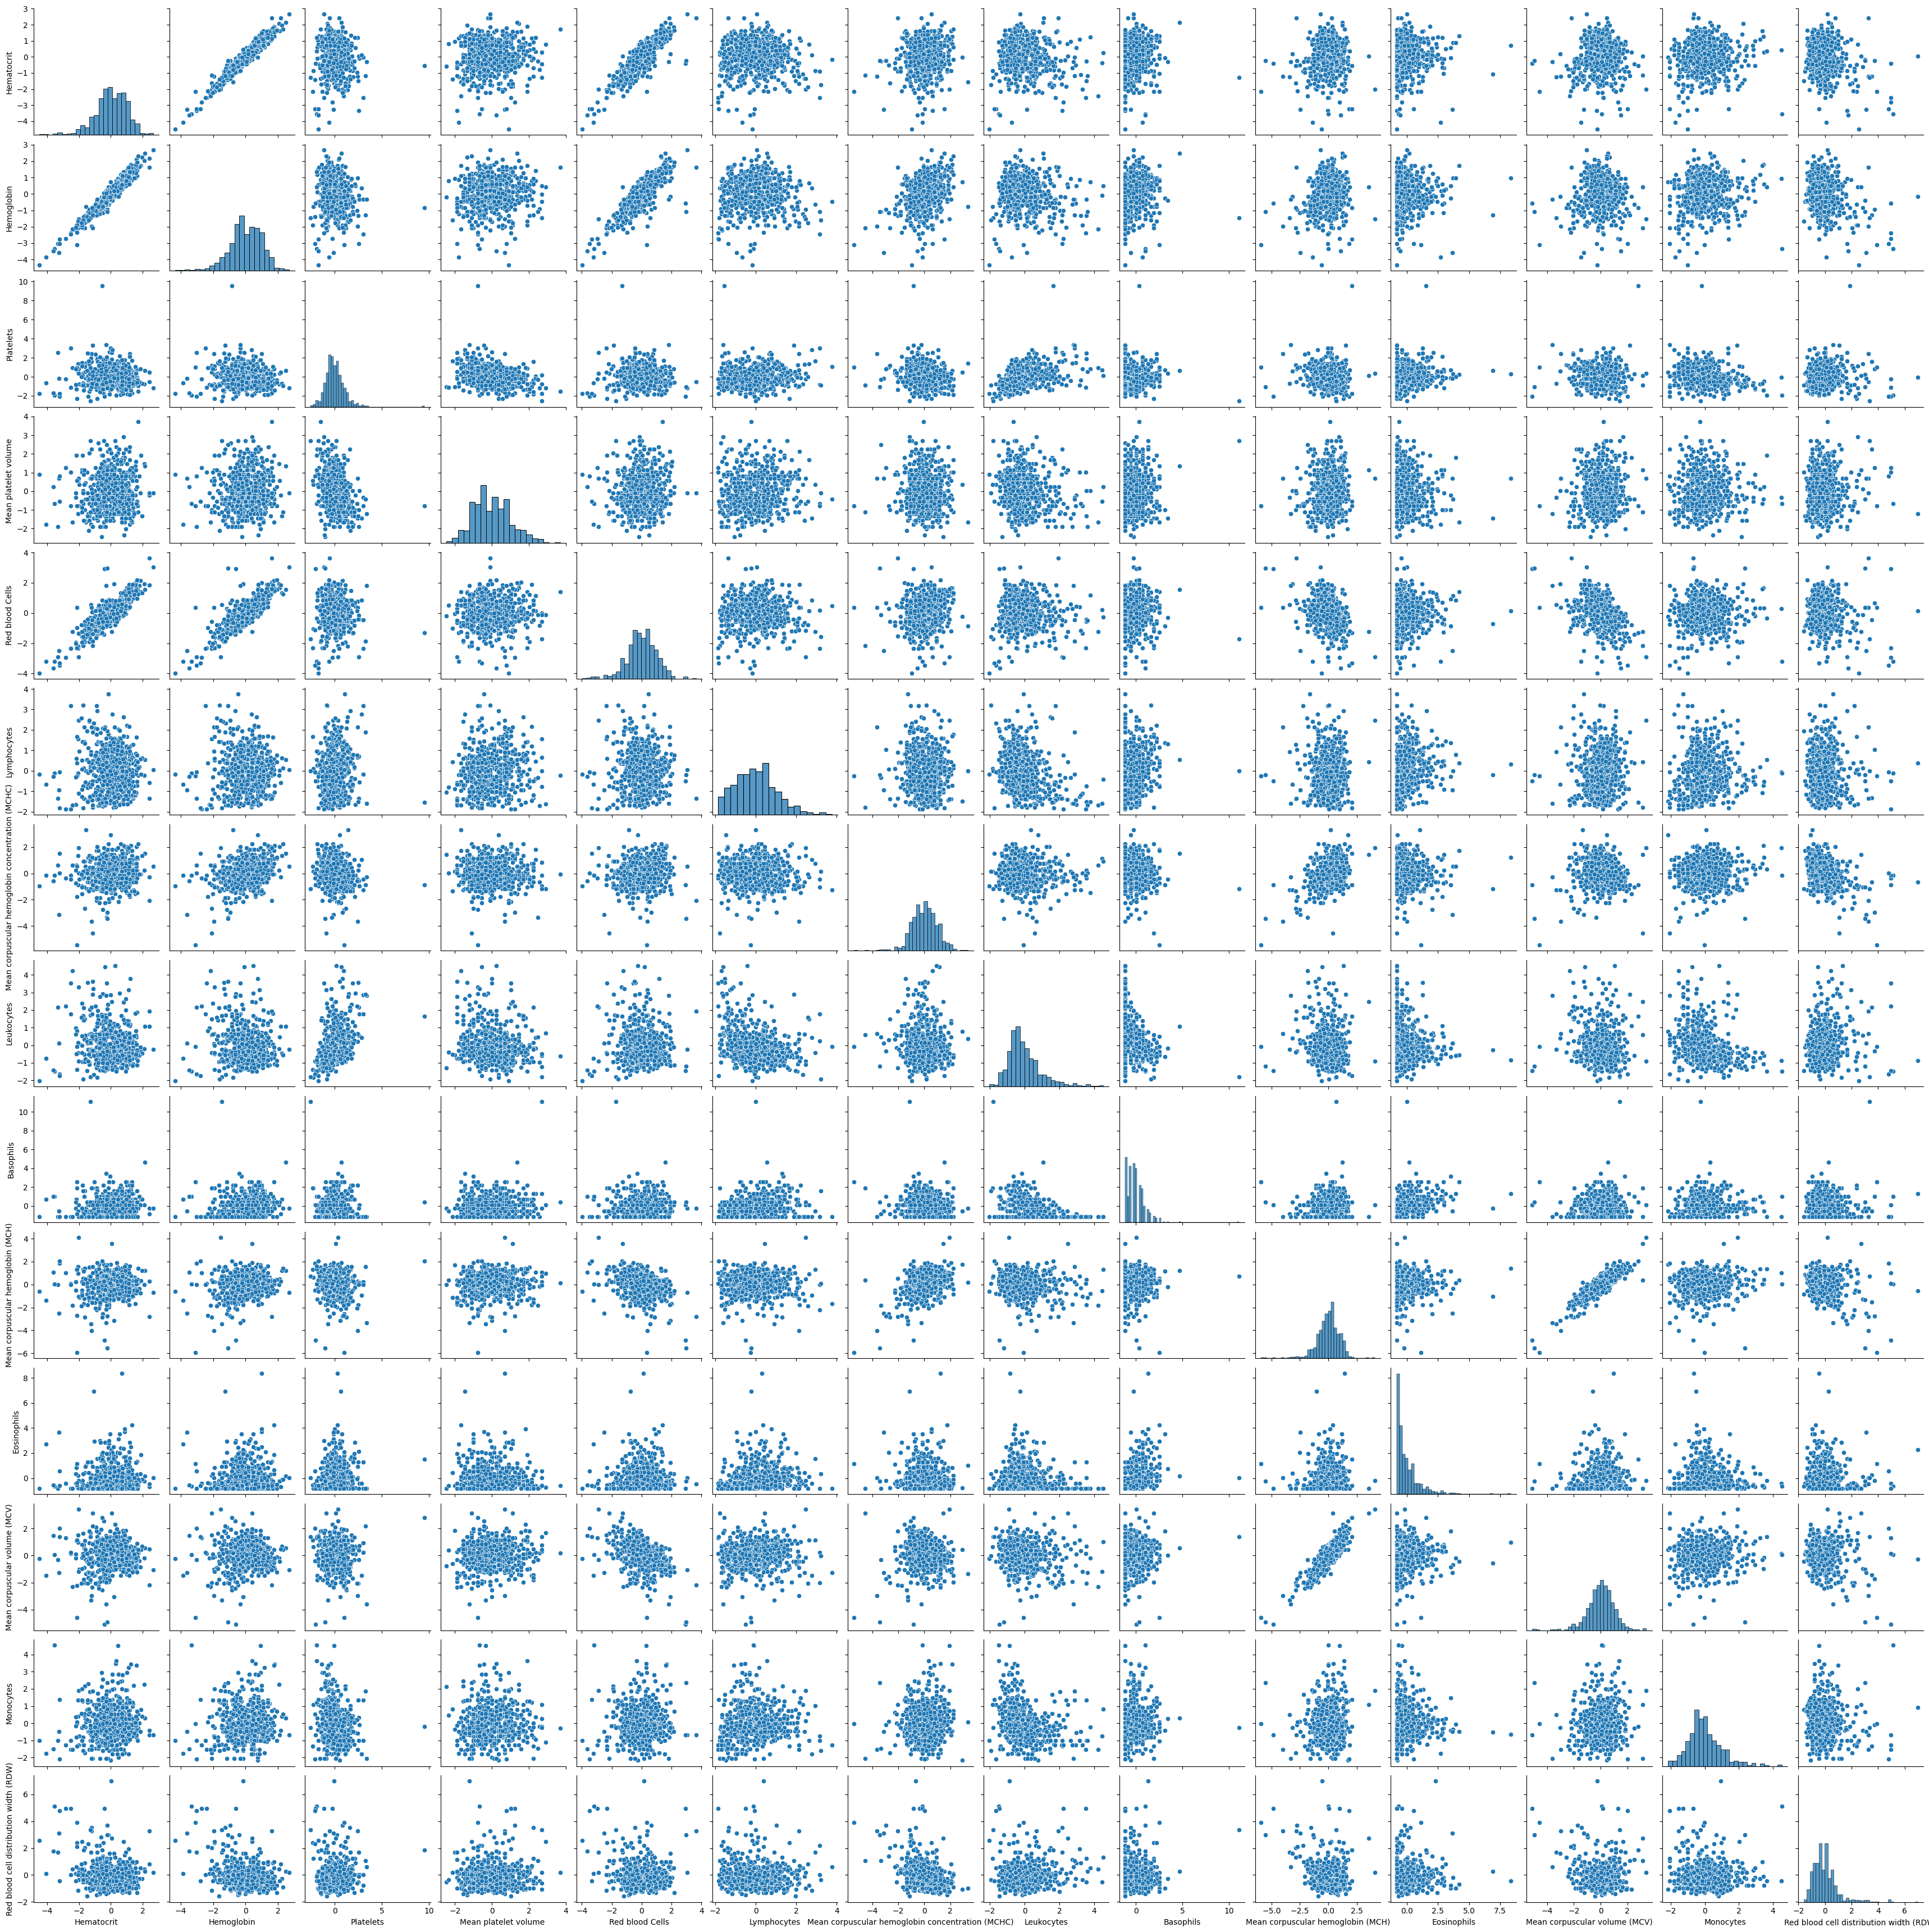

In [31]:
sns.pairplot(df[blood_columns])

<Axes: >

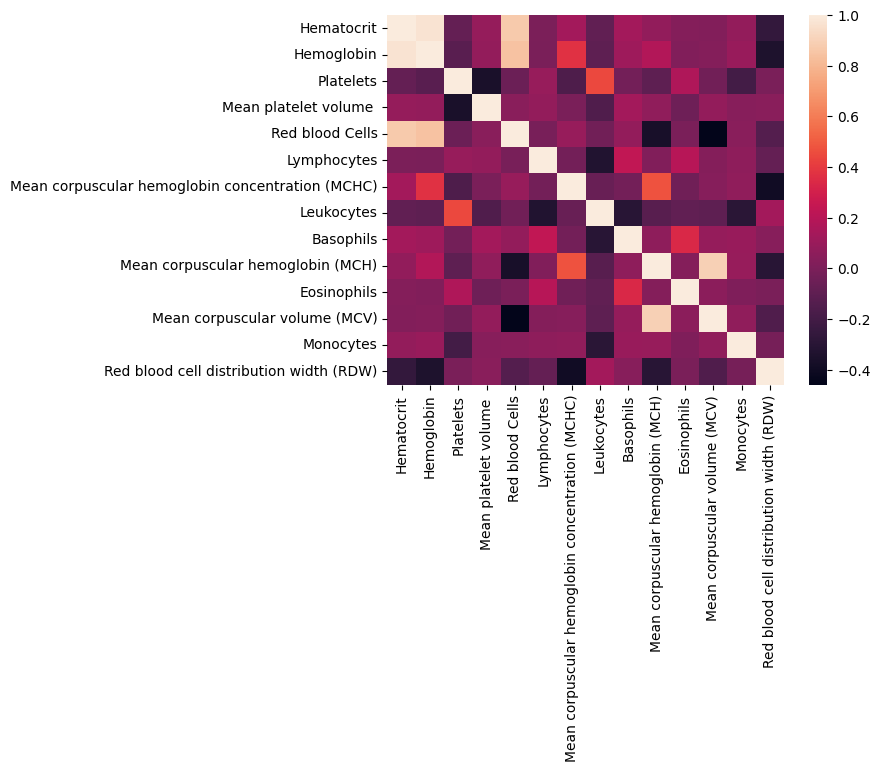

In [32]:
sns.heatmap(df[blood_columns].corr())

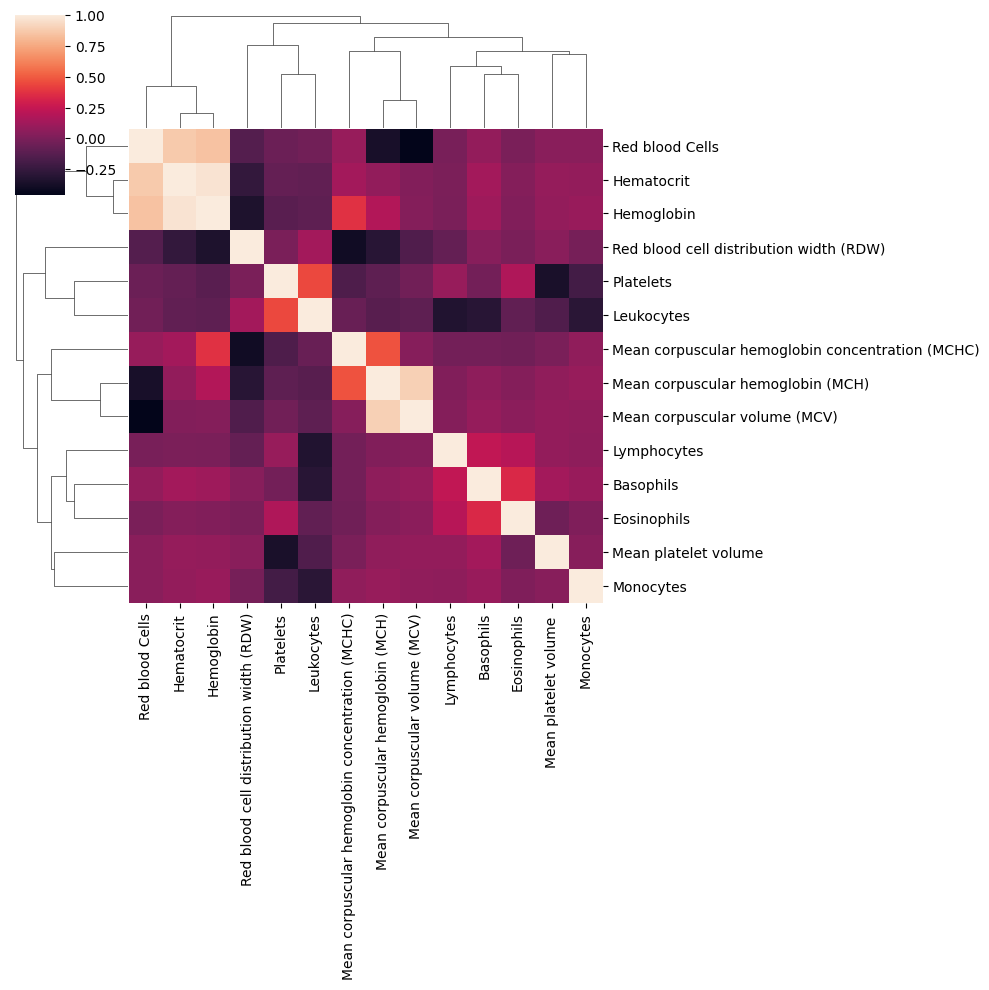

In [33]:
sns.clustermap(df[blood_columns].corr())

### **Blood data / age**

In [1]:
for col in blood_columns:
    plt.figure()
    sns.lmplot(x='Patient age quantile',y=col,hue=target_feature,data=df)

NameError: name 'blood_columns' is not defined

In [45]:
#Sélectionne que les valeurs chiffrées
df.select_dtypes(include=['number']).corr()['Patient age quantile'].sort_values()

# vraiment très peu de correlation entre l'âge et le reste

Leukocytes                                              -0.166386
Platelets                                               -0.158683
Lymphocytes                                             -0.125935
Mean corpuscular hemoglobin concentration (MCHC)        -0.124671
Red blood Cells                                         -0.037510
Patient addmited to intensive care unit (1=yes, 0=no)   -0.035772
Patient addmited to semi-intensive unit (1=yes, 0=no)    0.015736
Eosinophils                                              0.022085
Patient addmited to regular ward (1=yes, 0=no)           0.046166
Monocytes                                                0.050962
Hemoglobin                                               0.060320
Hematocrit                                               0.096808
Basophils                                                0.107525
Mean platelet volume                                     0.119449
Red blood cell distribution width (RDW)                  0.166429
Mean corpu

### **Relation Influenza / Rapid test**

In [46]:
pd.crosstab(df['Influenza A'],df['Influenza A, rapid test'])

"Influenza A, rapid test",negative,positive
Influenza A,,
detected,2,4
not_detected,245,15


In [47]:
pd.crosstab(df['Influenza B'],df['Influenza B, rapid test'])

"Influenza B, rapid test",negative,positive
Influenza B,,
detected,18,11
not_detected,233,4


### **Relation Viral / Blood data**

In [53]:
df['est malade']=np.sum(df[viral_columns[:-2]]=='detected',axis=1)>=1
#on élimine les 2 dernières colonnes
#on a 1 si y a une seule maladie détectée, 3 si testé positif à 3 test

In [54]:
df.head()

,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,"Influenza B, rapid test","Influenza A, rapid test",est malade
0,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,negative,negative,True
2,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,5,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,15,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,NaN,NaN,True


In [56]:
malade_df=df[df['est malade']==True]
non_malade_df=df[df['est malade']==False]

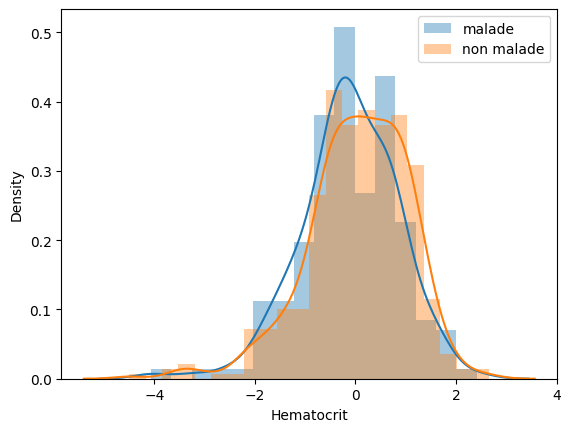

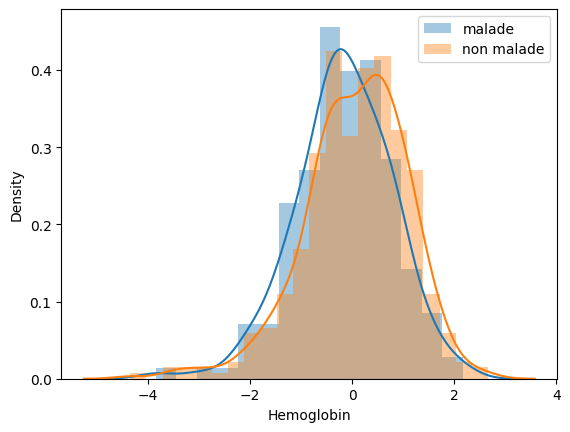

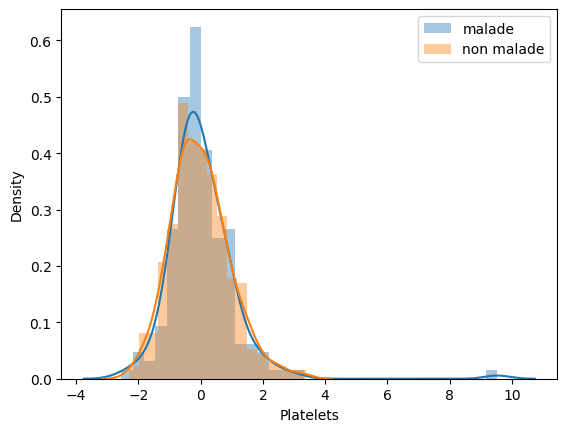

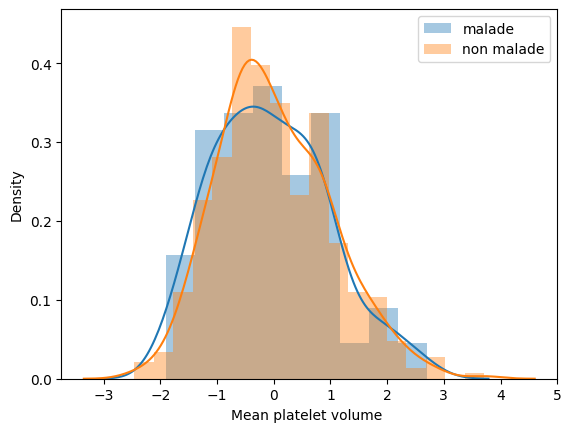

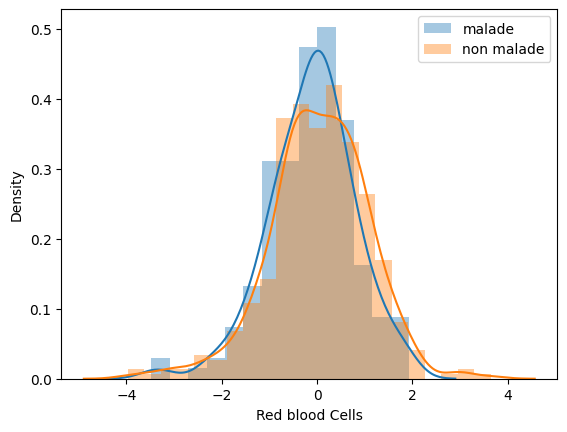

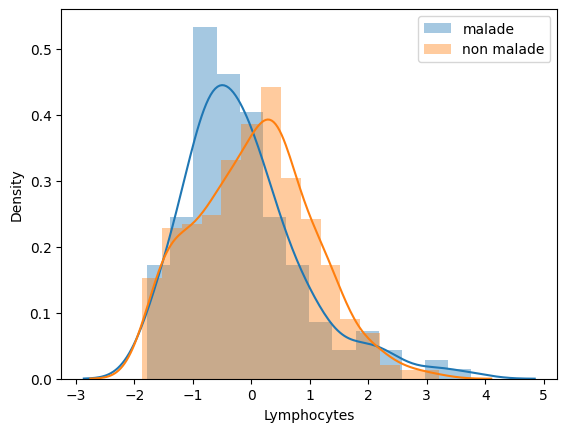

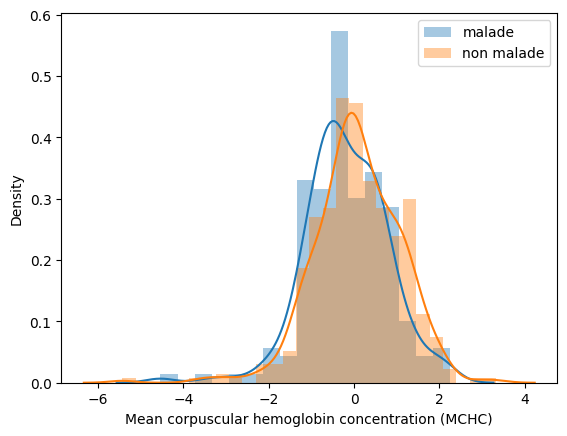

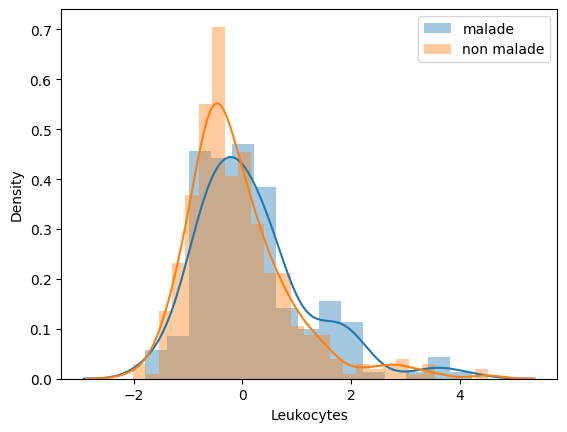

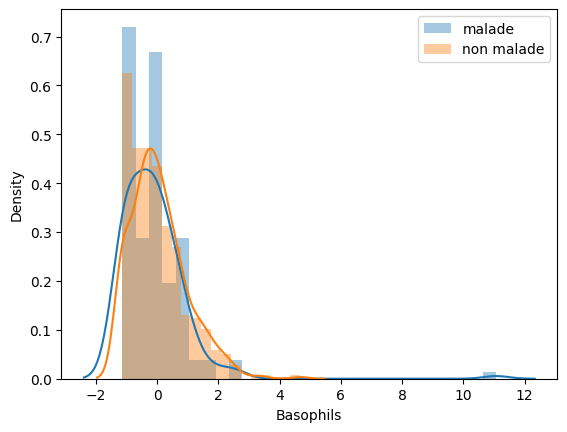

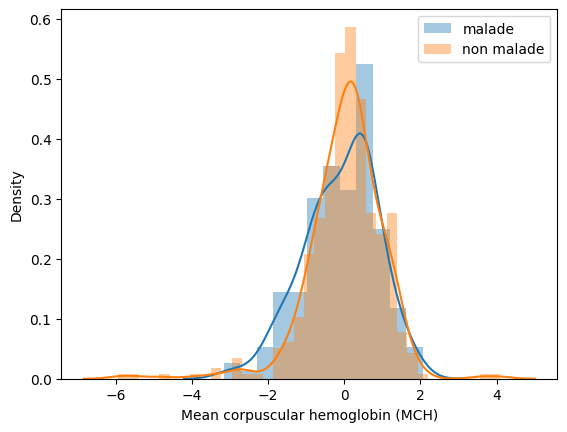

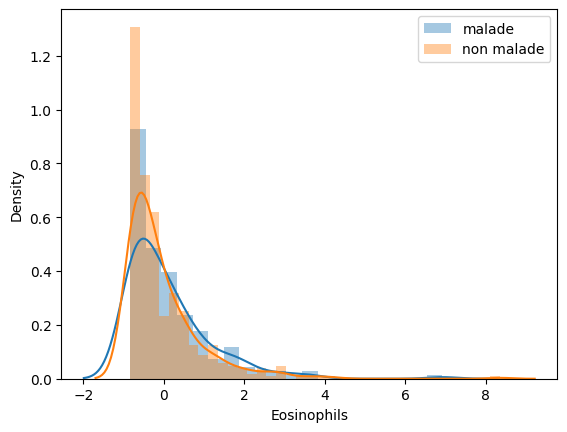

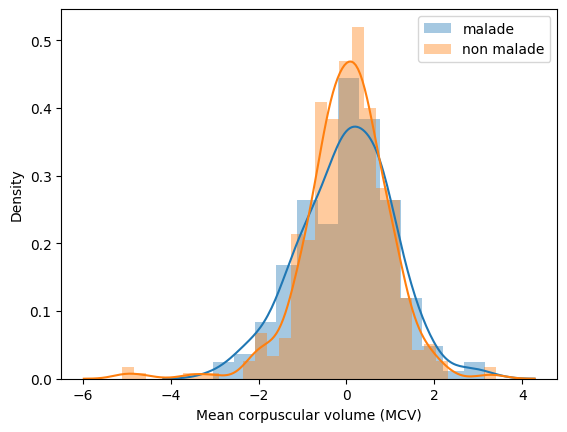

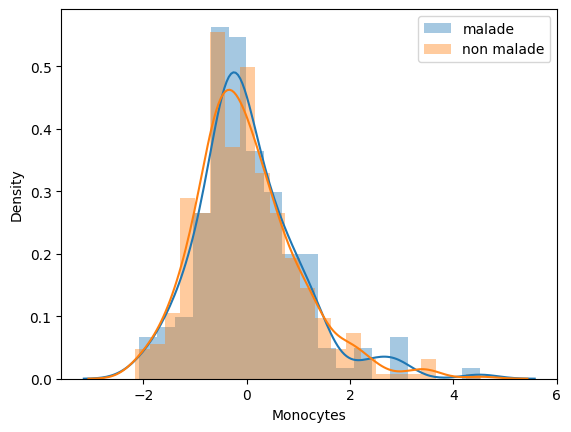

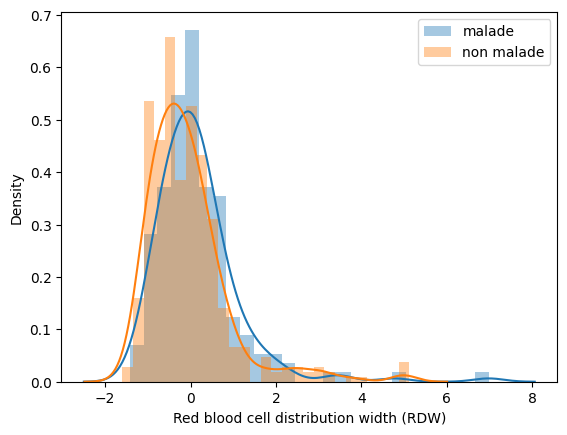

In [57]:
for col in blood_columns:
    plt.figure()
    sns.distplot(malade_df[col],label='malade')
    sns.distplot(non_malade_df[col],label='non malade')
    plt.legend()

### **Relation Hospitalisation / Viral**

In [58]:
df.head()

,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,"Influenza B, rapid test","Influenza A, rapid test",est malade
0,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,negative,negative,True
2,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,5,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,15,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,NaN,NaN,True


In [59]:
def hospitalisation(df):
    if df['Patient addmited to regular ward (1=yes, 0=no)']==1:
        return 'surveillance'
    elif df['Patient addmited to semi-intensive unit (1=yes, 0=no)']==1:
        return 'soins semi-intensifs'
    elif df['Patient addmited to intensive care unit (1=yes, 0=no)']==1:
        return 'soins intensifs'
    else:
        return 'inconnu'

In [61]:
df['statut']=df.apply(hospitalisation,axis=1)

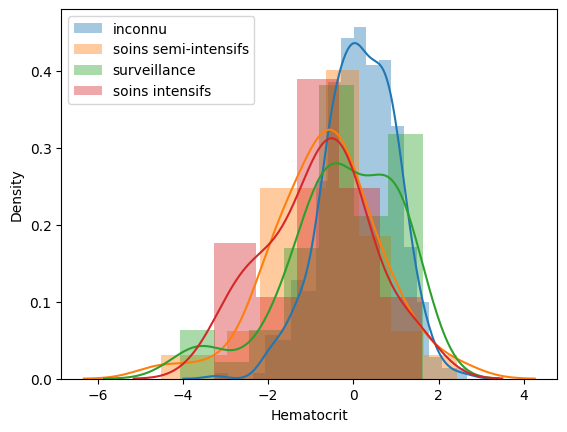

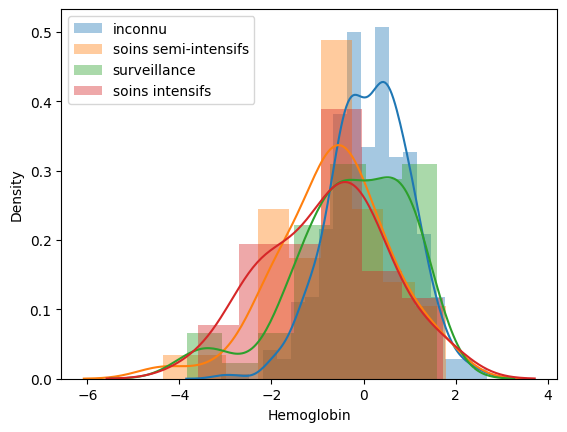

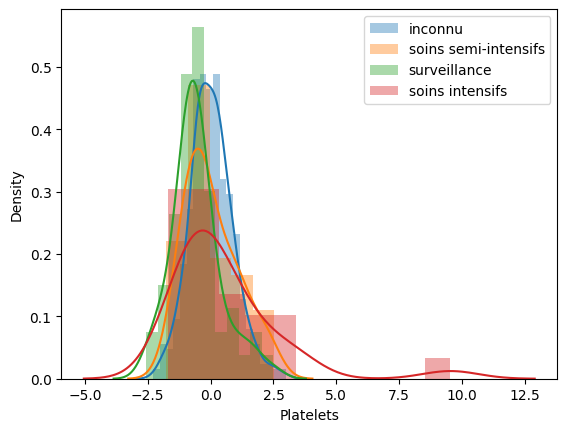

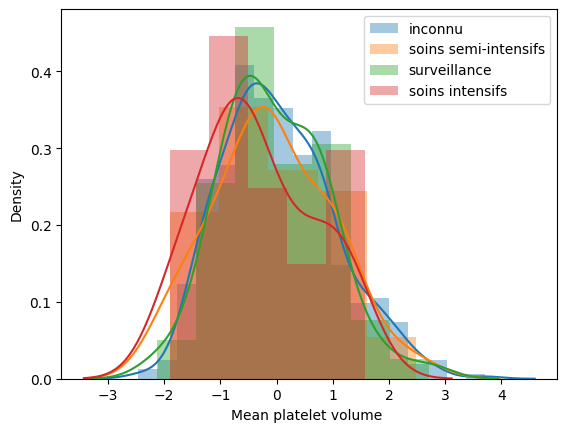

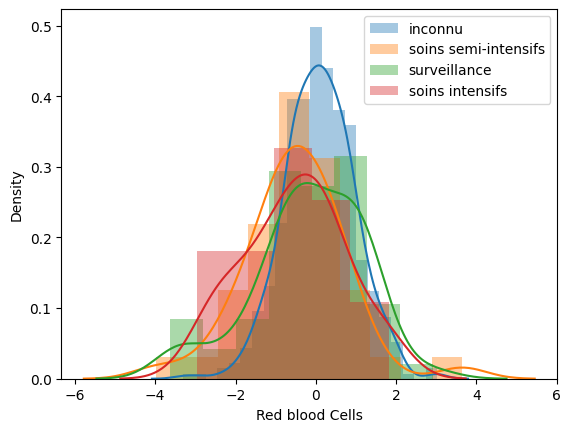

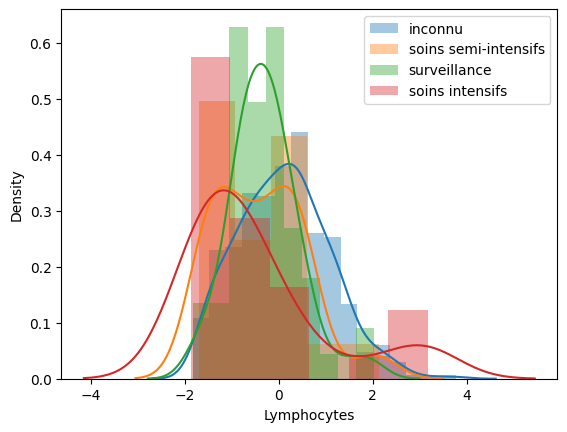

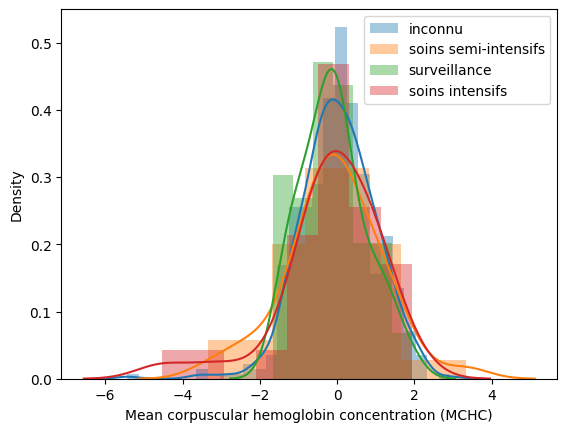

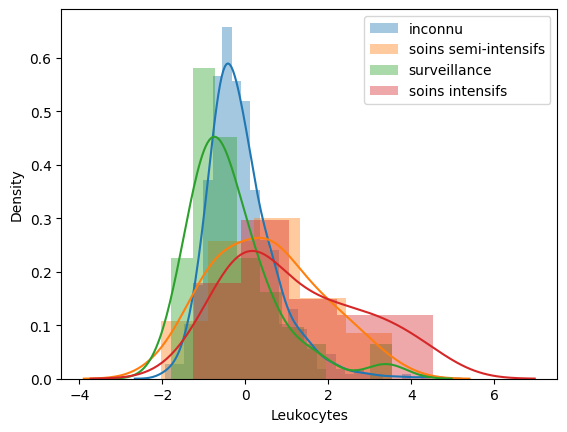

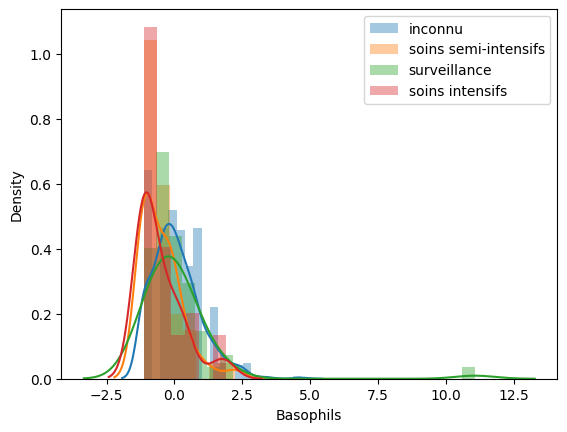

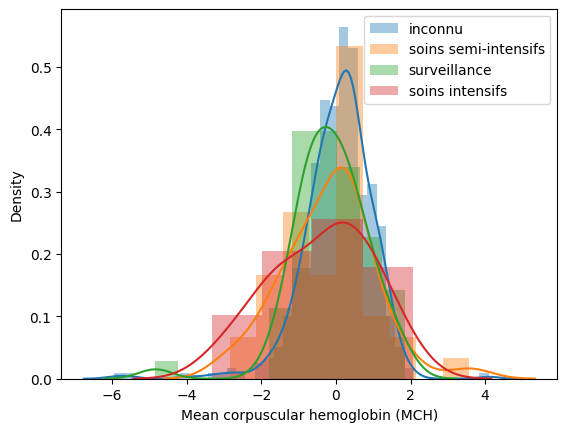

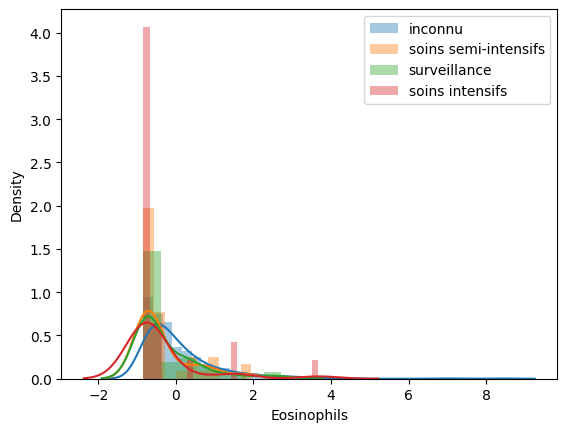

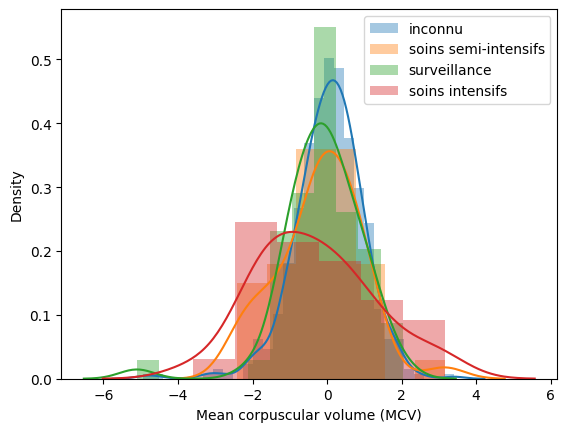

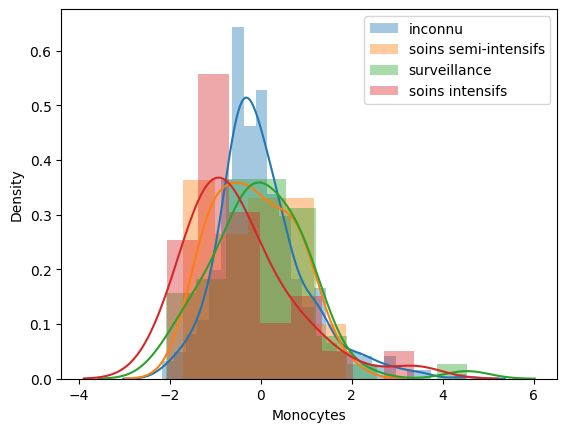

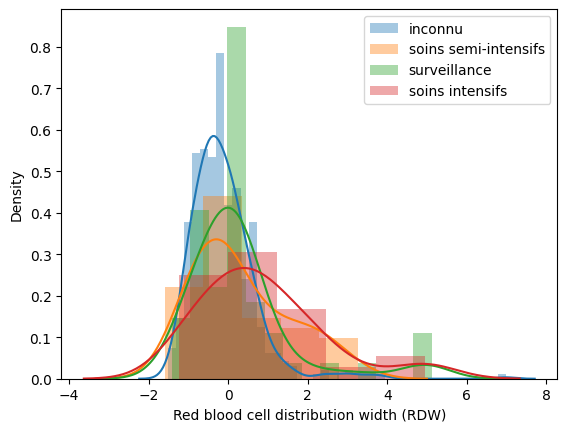

In [63]:
for col in blood_columns:
    plt.figure()
    for cat in df['statut'].unique():
        sns.distplot(df[df['statut']==cat][col],label=cat)
    plt.legend()

## **NaN Analyse**

In [66]:
print('Combien de lignes restent si on enlevait toutes celles avec un NaN : \n')
df.dropna().count()

Combien de lignes restent si on enlevait toutes celles avec un NaN : 



Patient age quantile                                     99
SARS-Cov-2 exam result                                   99
Patient addmited to regular ward (1=yes, 0=no)           99
Patient addmited to semi-intensive unit (1=yes, 0=no)    99
Patient addmited to intensive care unit (1=yes, 0=no)    99
Hematocrit                                               99
Hemoglobin                                               99
Platelets                                                99
Mean platelet volume                                     99
Red blood Cells                                          99
Lymphocytes                                              99
Mean corpuscular hemoglobin concentration (MCHC)         99
Leukocytes                                               99
Basophils                                                99
Mean corpuscular hemoglobin (MCH)                        99
Eosinophils                                              99
Mean corpuscular volume (MCV)           

In [70]:
df1=df[viral_columns[:-2]]
df1['covid']=df[target_feature]

print('Si on ne prend que les viral_columns, les proportions de covid sont :\n')
df1.dropna()['covid'].value_counts(normalize=True)

Si on ne prend que les viral_columns, les proportions de covid sont :



covid
negative    0.91716
positive    0.08284
Name: proportion, dtype: float64

In [71]:
df2=df[blood_columns[:-2]]
df2['covid']=df[target_feature]

print('Si on ne prend que les blood_columns, les proportions de covid sont :\n')
df2.dropna()['covid'].value_counts(normalize=True)

Si on ne prend que les blood_columns, les proportions de covid sont :



covid
negative    0.864775
positive    0.135225
Name: proportion, dtype: float64

## **Hypothèses nulles**

**Test de Student**

**H0= les taux moyens sont EGAUX chez les individus positifs et négatifs**

In [72]:
from scipy.stats import ttest_ind

In [74]:
negative_df.shape
positive_df.shape

(558, 38)

In [78]:
print('Pour avoir autant de négatifs que de positifs, on va prendre 558 négatifs au hasard dans notre negative_df')
balanced_neg=negative_df.sample(positive_df.shape[0])

Pour avoir autant de négatifs que de positifs, on va prendre 558 négatifs au hasard dans notre negative_df


In [79]:
def t_test(col):
    alpha=0.02
    stat,p=ttest_ind(balanced_neg[col].dropna(),positive_df[col].dropna())
    if p<alpha:
        return 'H0 rejetée'
    else:
        return 0

In [82]:
for col in blood_columns:
    print(f'{col:-<50} {t_test(col)}')

Hematocrit---------------------------------------- H0 rejetée
Hemoglobin---------------------------------------- H0 rejetée
Platelets----------------------------------------- H0 rejetée
Mean platelet volume ----------------------------- 0
Red blood Cells----------------------------------- H0 rejetée
Lymphocytes--------------------------------------- 0
Mean corpuscular hemoglobin concentration (MCHC)-- 0
Leukocytes---------------------------------------- H0 rejetée
Basophils----------------------------------------- 0
Mean corpuscular hemoglobin (MCH)----------------- 0
Eosinophils--------------------------------------- H0 rejetée
Mean corpuscular volume (MCV)--------------------- 0
Monocytes----------------------------------------- H0 rejetée
Red blood cell distribution width (RDW)----------- 0


# 3. Pre-processing
**Objectif** : Transformer le dataset pour le préparer au Machine Learning

* Création du Train / Test set
* Elimination des NaN : dropna(),imputation
* Encodage
* Suppression des outliers néfastes au modèle
* Feature Selection
* Feature Engineering
* Feature Scaling

# 4. Modelling
**Objectif** : développer un modèle de Machine Learning
 qui réponde à l'objectif final
 
* Définir une fonction d'évaluation
* Entrainement de différents modèles
* Optimisation avec GridSearchCV
* (Optionnel) Analyse des erreurs et retour au Preprocessing/EDA
* Learning Curve et prise de décision